<a href="https://www.mbd.rwth-aachen.de/">
    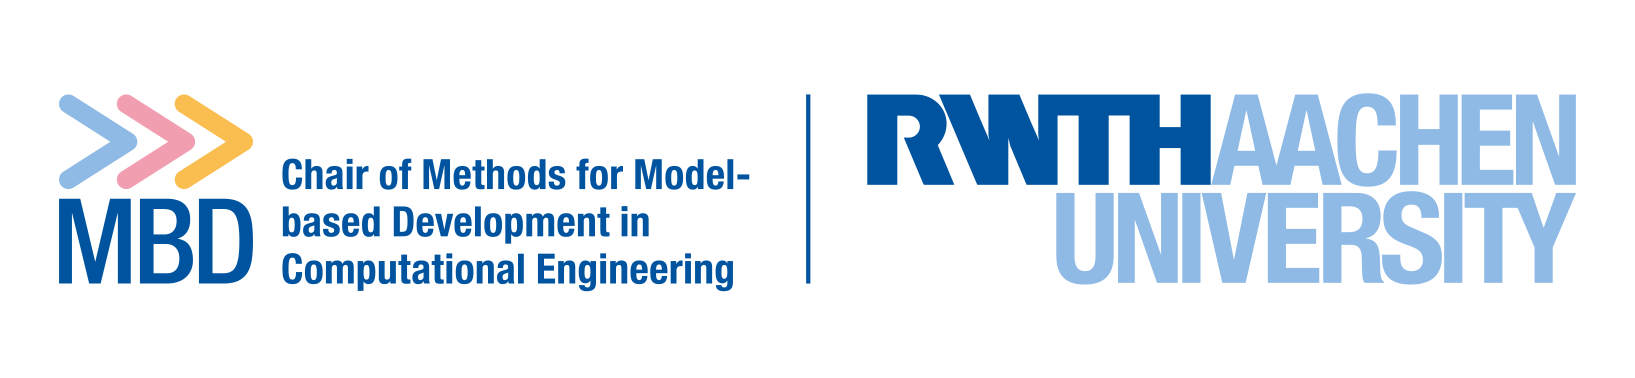
</a>
<a href="https://www.cpbl.rwth-aachen.de/">
    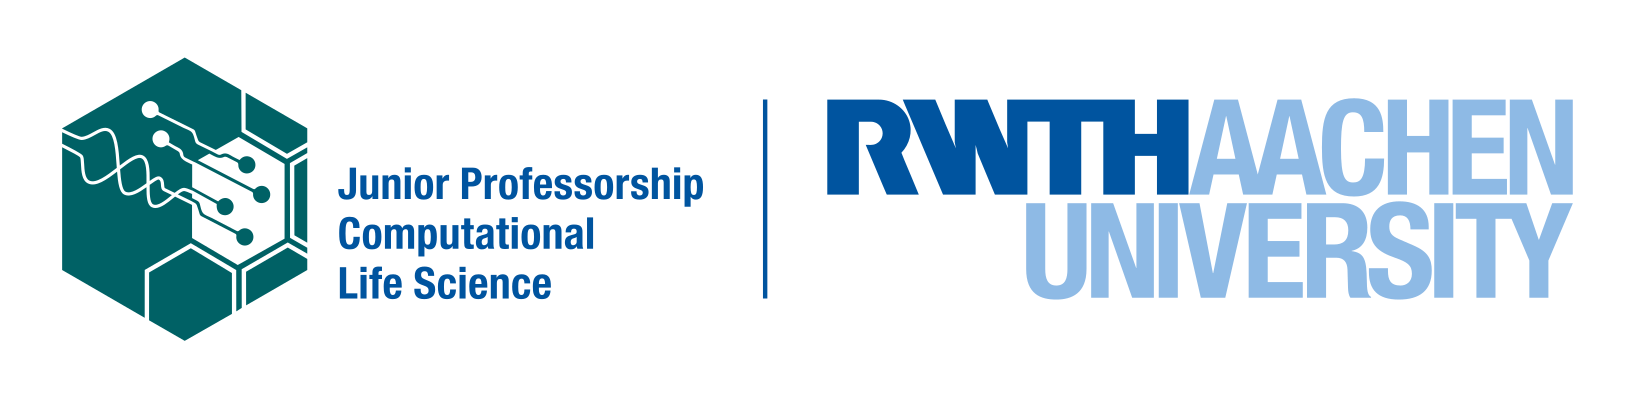
</a>

# Societal Challenges Datathon

Name: **Yajesh Chandra**

Student number (Matrikelnummer): **FILL-ME**

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [71]:

# Load data
df = pd.read_csv('data/combined_data.csv')
numeric_df = df.select_dtypes(include=[np.number])
diabetes_cols = ['EverTold_Diabetes', 'Age_DiabetesDiagnosis', 'EverTold_Prediabetes']

# Dictionary to store top features for each target
top_features_dict = {}
n_top = 20  # Number of top features to consider

for target_col in diabetes_cols:
    print(f"Analyzing correlations with: {target_col}\n")
    
    # Calculate correlations
    diabetes_correlations = numeric_df.corrwith(df[target_col]).dropna()
    
    # Sort by absolute correlation value and exclude self-correlation
    diabetes_correlations_sorted = diabetes_correlations.abs().sort_values(ascending=False)
    diabetes_correlations_sorted_filtered = diabetes_correlations_sorted.iloc[1:]
    
    # Get top N features
    top_features = diabetes_correlations_sorted_filtered.head(n_top).index.tolist()
    top_features_dict[target_col] = set(top_features)
    
    print(f"Top {n_top} variables correlated with {target_col}:")
    print("="*60)
    for var in top_features:
        corr_val = diabetes_correlations[var]
        print(f"{var:40s}: {corr_val:7.4f}")
    print("\n")

# Find common features across all three targets
common_features = top_features_dict[diabetes_cols[0]]
for target_col in diabetes_cols[1:]:
    common_features = common_features.intersection(top_features_dict[target_col])

print("="*60)
print("COMMON FEATURES ACROSS ALL THREE DIABETES VARIABLES")
print("="*60)
print(f"\nNumber of common features: {len(common_features)}")
print("\nCommon features:")
for idx, feature in enumerate(sorted(common_features), 1):
    print(f"{idx}. {feature}")

# Create a summary DataFrame showing correlations for common features
if len(common_features) > 0:
    summary_data = []
    for feature in sorted(common_features):
        row = {'Feature': feature}
        for target_col in diabetes_cols:
            corr = numeric_df[feature].corr(df[target_col])
            row[target_col] = corr
        row['Avg_Abs_Corr'] = np.mean([abs(row[col]) for col in diabetes_cols])
        summary_data.append(row)
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('Avg_Abs_Corr', ascending=False)
    
    print("\n" + "="*60)
    print("CORRELATION VALUES FOR COMMON FEATURES")
    print("="*60)
    print(summary_df.to_string(index=False))
    
    # Save to CSV
    summary_df.to_csv('common_diabetes_features.csv', index=False)
    print("\n✓ Results saved to 'common_diabetes_features.csv'")
else:
    print("\n⚠ No common features found in top 20 across all three variables.")
    print("Consider increasing 'n_top' value or analyzing feature overlap separately.")

# Additional analysis: Features appearing in at least 2 out of 3 targets
print("\n" + "="*60)
print("FEATURES APPEARING IN AT LEAST 2 OUT OF 3 TARGETS")
print("="*60)

all_features = set()
for features in top_features_dict.values():
    all_features.update(features)

feature_counts = {}
for feature in all_features:
    count = sum(1 for features in top_features_dict.values() if feature in features)
    if count >= 2:
        feature_counts[feature] = count

# Sort by count
sorted_features = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\nTotal features appearing in at least 2 targets: {len(sorted_features)}")
print("\nFeature breakdown:")
for feature, count in sorted_features:
    targets = [col for col in diabetes_cols if feature in top_features_dict[col]]
    print(f"\n{feature} (appears in {count}/3 targets)")
    print(f"  Targets: {', '.join(targets)}")
    for target in targets:
        corr = numeric_df[feature].corr(df[target])
        print(f"  - {target}: {corr:.4f}")

Analyzing correlations with: EverTold_Diabetes

Top 20 variables correlated with EverTold_Diabetes:
CurrentlyTaking_DiabeticPills           :  0.3985
DifficultyHearing_Level                 :  0.3156
PrescriptionMeds_Count_Last30Days       : -0.2860
ProductsUsed_4                          :  0.2492
NumberOfDaysSmokedPipe_5Days            :  0.2224
GeneralHealth_Status                    : -0.2005
DifficultyWalkingClimbingSteps_Level    : -0.1943
EverTold_Hypertension                   :  0.1720
PrescriptionMedication_Used_Last30Days  :  0.1637
CurrentlyTaking_CholesterolMedication   :  0.1538
DifficultyUsingHandsFingers_Level       : -0.1445
AdultDisabilityIndicator                :  0.1376
OverallHealth_TeethAndGums              : -0.1351
EverTold_TakeAspirin                    :  0.1337
AdultEnhancedDisabilityIndicator        :  0.1330
EverTold_HighCholesterol                :  0.1162
WorkExperience_LastWeek                 : -0.1153
ImpactOfLeakageOnLife_12Months          : -0.1138


c:\Users\Yajesh\Workspace\Societal-challenges-datathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Yajesh\Workspace\Societal-challenges-datathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Yajesh\Workspace\Societal-challenges-datathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Yajesh\Workspace\Societal-challenges-datathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Yajesh\Workspace\Societal-challenges-datathon\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [72]:
#Load data files

#predictor variables
alcohol_use = pd.read_csv('main_focus/alcohol_use.csv')
blood_pressure_cholesterol = pd.read_csv('main_focus/blood_pressure_cholesterol.csv')
diet_behaviors = pd.read_csv('main_focus/diet_behavior_nutrition.csv')
physical_activity = pd.read_csv('main_focus/physical_activity.csv')
physical_activity_youth = pd.read_csv('main_focus/physical_activity_youth.csv')
sleep_disorders = pd.read_csv('main_focus/sleep_disorders.csv')
smoking_cigarette_use = pd.read_csv('main_focus/smoking_cigarette_use.csv')
smoking_household_smokers = pd.read_csv('main_focus/smoking_household_smokers.csv')
smoking_recent_tobacco_use = pd.read_csv('main_focus/smoking_recent_tobacco_use.csv')
audiometry = pd.read_csv('main_focus/audiometry.csv')
functioning = pd.read_csv('main_focus/functioning.csv')
hospital_utils = pd.read_csv('main_focus/hospital_utilization_access_to_care.csv')

#target variable
diabetes = pd.read_csv('main_focus/diabetes.csv')
# combined_data = pd.read_csv('data/combined_data.csv')



In [73]:
alcohol_use_df = alcohol_use.head()
blood_pressure_cholesterol_df = blood_pressure_cholesterol.head()
diet_behaviors_df = diet_behaviors.head()
physical_activity_df = physical_activity.head()
physical_activity_youth_df = physical_activity_youth.head()
sleep_disorders_df = sleep_disorders.head()
smoking_cigarette_use_df = smoking_cigarette_use.head()
smoking_household_smokers_df = smoking_household_smokers.head()
smoking_recent_tobacco_use_df = smoking_recent_tobacco_use.head()
audiometry_df = audiometry.head()
functioning_df = functioning.head()
hospital_utils_df = hospital_utils.head()
diabetes_df = diabetes.head()



print(alcohol_use_df)
print("="*100)
print(blood_pressure_cholesterol_df)
print("="*100)
print(diet_behaviors_df)
print("="*100)
print(physical_activity_df)
print("="*100)
print(physical_activity_youth_df)
print("="*100)
print(sleep_disorders_df)
print("="*100)
print(smoking_cigarette_use_df)
print("="*100)
print(smoking_household_smokers_df)
print("="*100)
print(smoking_recent_tobacco_use_df)
print("="*100)
print(audiometry_df)
print("="*100)
print(functioning_df)
print("="*100)
print(hospital_utils_df)
print("="*100)
print(diabetes_df)



   sequence_no  EverHad_Alcohol  AlcoholConsumptionFrequency_12Months  \
0     130378.0              NaN                                   NaN   
1     130379.0              1.0                          2.000000e+00   
2     130380.0              1.0                          1.000000e+01   
3     130386.0              1.0                          4.000000e+00   
4     130387.0              1.0                          5.397605e-79   

   AverageDrinksPerDrinkingDay_12Months  \
0                                   NaN   
1                                   3.0   
2                                   1.0   
3                                   2.0   
4                                   NaN   

   MoreThanSpecificNumberOfDrinksFrequency  \
0                                      NaN   
1                             5.397605e-79   
2                             5.397605e-79   
3                             1.000000e+01   
4                                      NaN   

   HeavyDrinkingWithinTwo

In [74]:
alcohol_use_columns = [
    "sequence_no",
    "EverHad_Alcohol",
    "AlcoholConsumptionFrequency_12Months",
    "AverageDrinksPerDrinkingDay_12Months",
    "MoreThanSpecificNumberOfDrinksFrequency",
    "HeavyDrinkingWithinTwoHoursFrequency_12Months",
    "MoreThan8DrinksPerDay_12Months",
    "DailyHeavyDrinkingHistory",
    "OccasionsWithHeavyDrinking_30Days",
]

blood_pressure_cholesterol_columns = [
    "sequence_no",
    "EverTold_Hypertension",
    "ConfirmedHypertension_Visits",
    "CurrentlyTaking_BloodPressureMedication",
    "EverTold_HighCholesterol",
    "CurrentlyTaking_CholesterolMedication",
]

diet_behaviors_columns = [
    "sequence_no",
    "EverBreastfed",
    "AgeStoppedBreastfeeding",
    "AgeFirstFedFormula",
    "AgeStoppedDrinkingFormula",
    "AgeFirstFedOtherThanBreastMilk_inDays",
    "AgeFirstFedMilk",
    "FirstTypeOfMilkFed_1",
    "FirstTypeOfMilkFed_2",
    "FirstTypeOfMilkFed_3",
    "FirstTypeOfMilkFed_4",
    "FirstTypeOfMilkFed_5",
    "FirstTypeOfMilkFed_6",
    "MealsDeliveredHome_Past12Months",
    "AttendedCommunityMeals_Past12Months",
    "CurrentlyAttendingSchool",
    "SchoolServesLunches",
    "NumberWeeklyCompleteSchoolLunches",
    "LunchCostStatus",
    "SchoolServesBreakfastsAtConstantCostsDaily",
    "NumberWeeklyCompleteSchoolBreakfasts",
    "BreakfastCostStatus",
    "SummerProgramMealCostsStatus",
    "MealPlanningResponsibility",
    "MealPreparationSharing",
    "FoodShoppingResponsibility",
    "FoodShoppingSharing",
]

physical_activity_columns = [
    "sequence_no",
    "Frequency_ModerateActivity",
    "Frequency_ModerateActivity.1",
    "Duration_ModerateActivity_PerSession",
    "Frequency_VigorousActivity",
    "Frequency_VigorousActivity.1",
    "Duration_VigorousActivity_PerSession",
    "SittingTime_TypicalDay",
]

physical_activity_youth_columns = [
    "sequence_no",
    "Days_PhysicallyActive_AtLeast60Min_Last7Days",
    "ScreenTime_TypicalDay_SchoolYear",
]

sleep_disorders_columns = [
    "sequence_no",
    "WeekdaySleepTime",
    "WeekdayWakeTime",
    "WeekdaySleepHours",
    "WeekendSleepTime",
    "WeekendWakeTime",
    "WeekendSleepHours",
]

smoking_cigarette_use_columns = [
    "sequence_no",
    "SmokedAtLeast100CigarettesInLife",
    "CurrentCigaretteSmoking",
    "CigarettesSmokedDays_30Days",
    "CigarettesPerDayOnSmokingDays_30Days",
    "SmokingTypeMenthol",
    "TotalCigarettesSmoked",
    "FirstCigaretteAge",
    "QuestionnaireModeFlag",
]

smoking_household_smokers_columns = [
    "sequence_no",
    "NumberOfPeopleSmokingInHome",
    "NumberOfPeopleSmokingInsideHome",
]

smoking_recent_tobacco_use_columns = [
    "sequence_no",
    "TabaccoProduct_5Days",
    "ProductsUsed_1",
    "DaysSmokedCigarettes_5Days",
    "CigarettesSmokedPerSmokingDay_5Days",
    "LastCigaretteSmoked",
    "ProductsUsed_2",
    "NumberOfDaysSmokedPipe_5Days",
    "ProductsUsed_3",
    "NumberOfDaysSmokedRegularCigars_5Days",
    "ProductsUsed_7",
    "NumberOfDaysSmokedWaterPipeHookah_5Days",
    "UsedECigarettes_5Days",
    "NumberOfDaysUsedECigarettes_5Days",
    "UsedSmokelessTobacco_5Days",
    "ProductsUsed_4",
    "ProductsUsed_5",
    "ProductsUsed_8",
    "UsedNicotineReplacement_5Days",
    "ProductsUsed_6",
    "UsedAnyTobaccoProduct_5Days",
]

audiometry_columns = [
"sequence_no",
"HearingStatus_NoAid",
"reason_hearing_loss_A",
"reason_hearing_loss_B",
"reason_hearing_loss_C",
"reason_hearing_loss_D",
"reason_hearing_loss_E",
"reason_hearing_loss_F",
"reason_hearing_loss_G",
"reason_hearing_loss_H",
"reason_hearing_loss_I",
"reason_hearing_loss_J",
"LastHearingTest_Specialist",
"DifficultyHearing_WithBackgroundNoise"
]

functioning_columns = [
    'sequence_no', 'DifficultySeeing_Level', 'DifficultyHearing_Level',
       'EquipmentForWalking', 'DifficultyWalkingWithoutAssistance_Level',
       'DifficultyWalkingComparedToPeers_Level',
       'DifficultyWithSelfCare_Level', 'DifficultyBeingUnderstoodAtHome_Level',
       'DifficultyBeingUnderstoodOutside_Level',
       'DifficultyLearningComparedToPeers_Level',
       'DifficultyRememberingComparedToPeers_Level',
       'DifficultyConcentratingOnEnjoyableActivities_Level',
       'DifficultyAcceptingRoutineChanges_Level',
       'DifficultyControllingBehavior_Level', 'DifficultyMakingFriends_Level',
       'FrequencyOfAnxiety_Level', 'FrequencyOfSadness_Level',
       'ChildDisabilityIndicator', 'DifficultySeeingWithGlasses_Level',
       'DifficultyHearingWithAid_Level',
       'DifficultyWalkingClimbingSteps_Level', 'DifficultyCommunicating_Level',
       'DifficultyRememberingConcentrating_Level', 'DifficultySelfCare_Level',
       'DifficultyLiftingWeight_Level', 'DifficultyUsingHandsFingers_Level',
       'FrequencyWorriedAnxious', 'LevelOfWorryAnxiety', 'FrequencyDepressed',
       'LevelOfDepression', 'AdultDisabilityIndicator',
       'AdultEnhancedDisabilityIndicator']

hospital_utils_columns = ['sequence_no', 'GeneralHealth_Status', 'HasUsualPlace_ForCare',
       'UsualPlace_Type', 'TelehealthAppointment_Past12Months',
       'MentalHealthVisit_Past12Months']

diabetes_columns = [
    "sequence_no",
    "EverTold_Diabetes",
    "Age_DiabetesDiagnosis",
    "EverTold_Prediabetes",
    "BloodSugarTest_Last3Years",
    "CurrentlyTaking_Insulin",
    "InsulinDuration",
    "Unnamed: 7",
    "CurrentlyTaking_DiabeticPills",
]


In [75]:
dataframes = {
    'alcohol_use': alcohol_use,
    'blood_pressure_cholesterol': blood_pressure_cholesterol,
    'diet_behaviors': diet_behaviors,
    'physical_activity': physical_activity,
    'physical_activity_youth': physical_activity_youth,
    'sleep_disorders': sleep_disorders,
    'smoking_cigarette_use': smoking_cigarette_use,
    'smoking_household_smokers': smoking_household_smokers,
    'smoking_recent_tobacco_use': smoking_recent_tobacco_use,
    'audiometry': audiometry,
    'functioning': functioning,
    'hospital_utils': hospital_utils,
    'diabetes': diabetes
    
}


In [76]:
for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"{'='*60}")
    print(f"Total rows: {len(df)}")
    print(f"Total columns: {len(df.columns)}")
    
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    missing_data = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Missing_Percent': missing_percent.values
    })
    
    # Sort by missing count descending
    missing_data_sorted = missing_data.sort_values('Missing_Count', ascending=False)
    
    print(f"\nAll columns ({len(df.columns)} total):")
    print(missing_data_sorted.to_string(index=False))
    
    # Summary of columns with missing values
    columns_with_missing = len(missing_data[missing_data['Missing_Count'] > 0])
    print(f"\nColumns with missing values: {columns_with_missing} out of {len(df.columns)}")
    
    total_missing = missing.sum()
    total_cells = len(df) * len(df.columns)
    print(f"\nTotal missing values: {total_missing} out of {total_cells} cells ({(total_missing/total_cells)*100:.2f}%)")


Dataset: alcohol_use
Total rows: 6337
Total columns: 9

All columns (9 total):
                                       Column  Missing_Count  Missing_Percent
            OccasionsWithHeavyDrinking_30Days           3979        62.789964
               MoreThan8DrinksPerDay_12Months           3975        62.726842
HeavyDrinkingWithinTwoHoursFrequency_12Months           3971        62.663721
         AverageDrinksPerDrinkingDay_12Months           2268        35.789806
      MoreThanSpecificNumberOfDrinksFrequency           2255        35.584662
                    DailyHeavyDrinkingHistory           1436        22.660565
         AlcoholConsumptionFrequency_12Months           1415        22.329178
                              EverHad_Alcohol            856        13.507969
                                  sequence_no              0         0.000000

Columns with missing values: 8 out of 9

Total missing values: 20155 out of 57033 cells (35.34%)

Dataset: blood_pressure_cholesterol
Total


Dataset: alcohol_use
Total rows: 6337
Total columns: 9


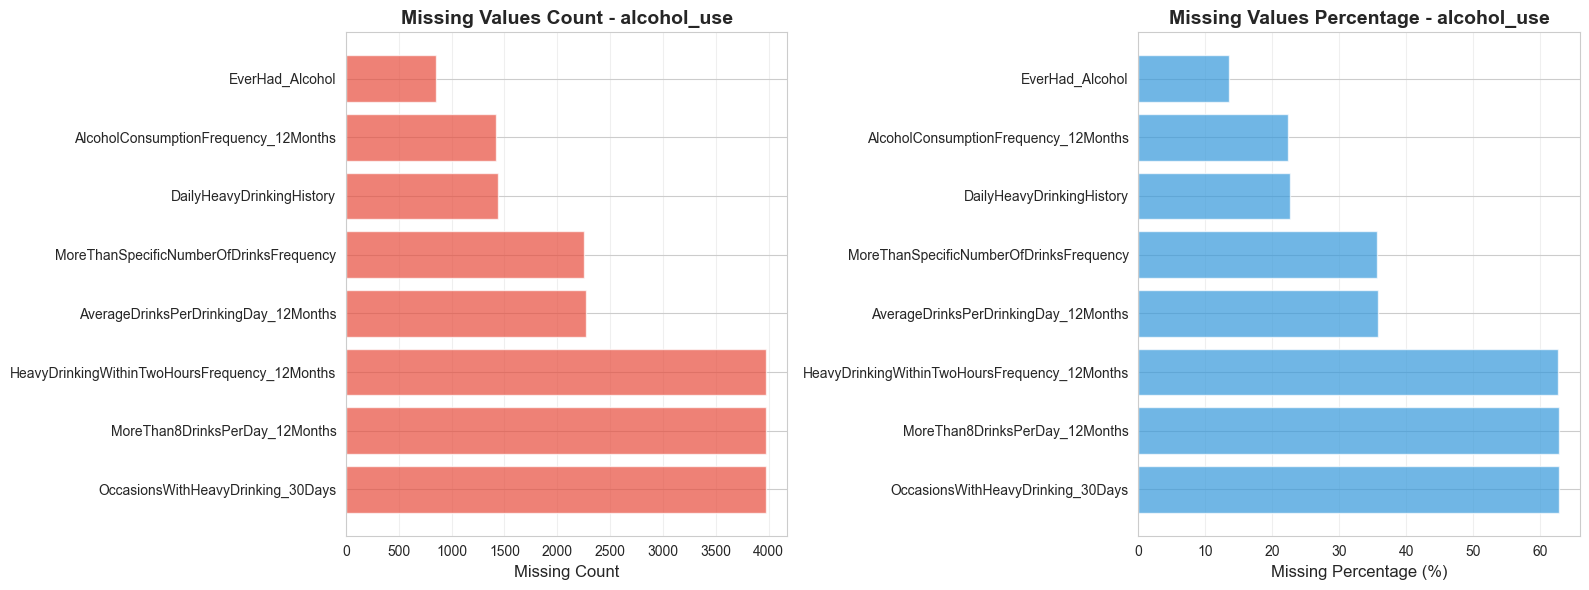




Dataset: blood_pressure_cholesterol
Total rows: 8501
Total columns: 6


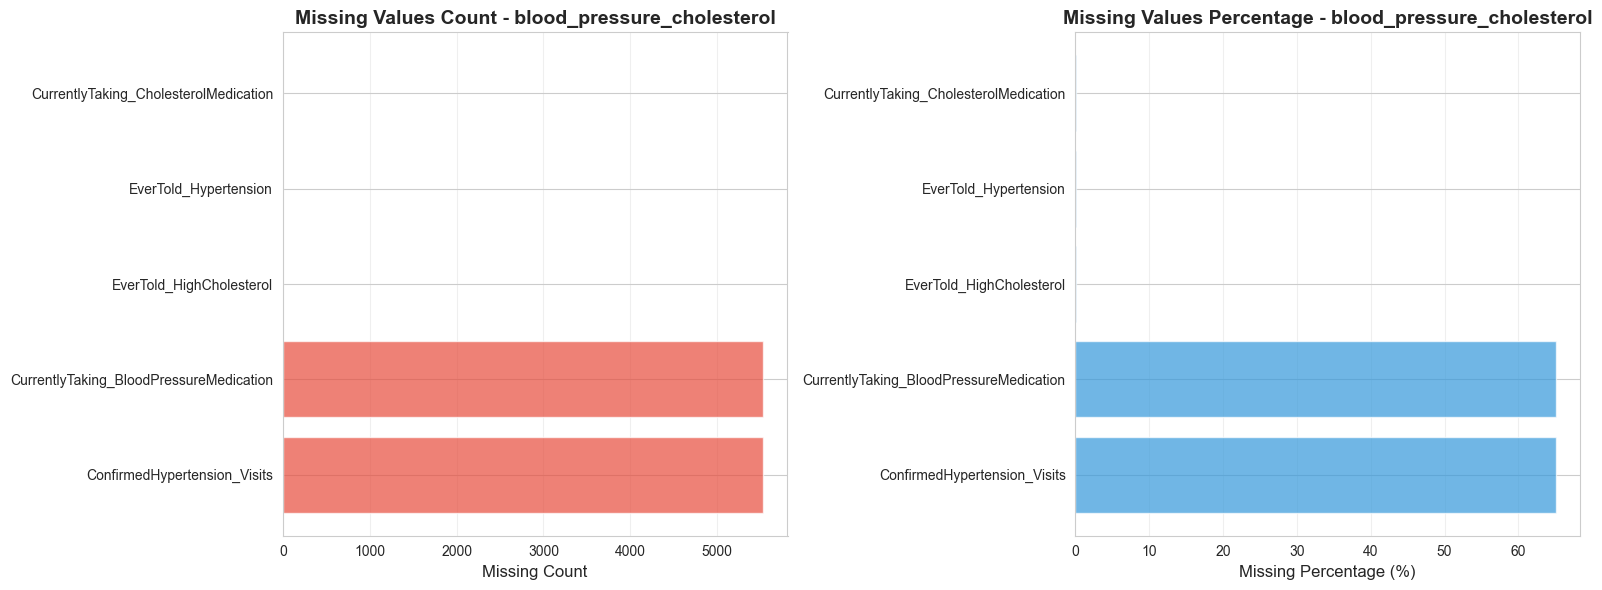




Dataset: diet_behaviors
Total rows: 11933
Total columns: 27


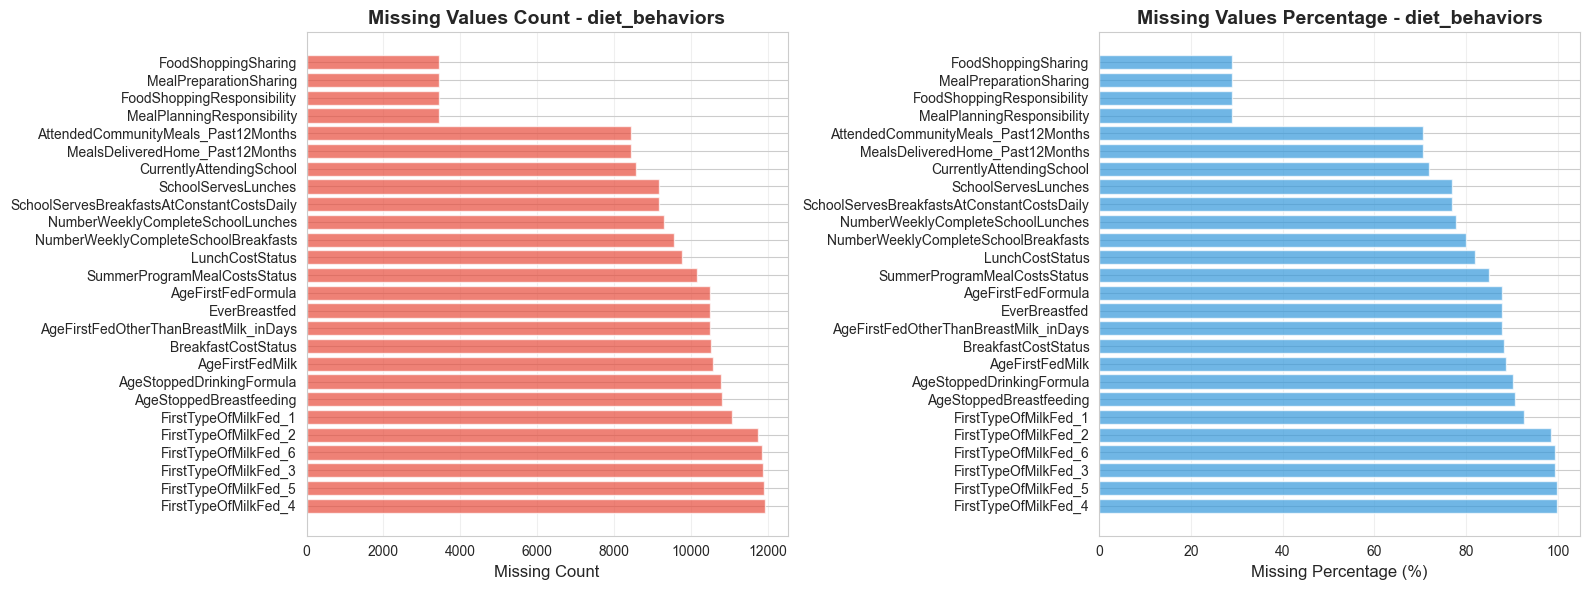




Dataset: physical_activity
Total rows: 8153
Total columns: 8


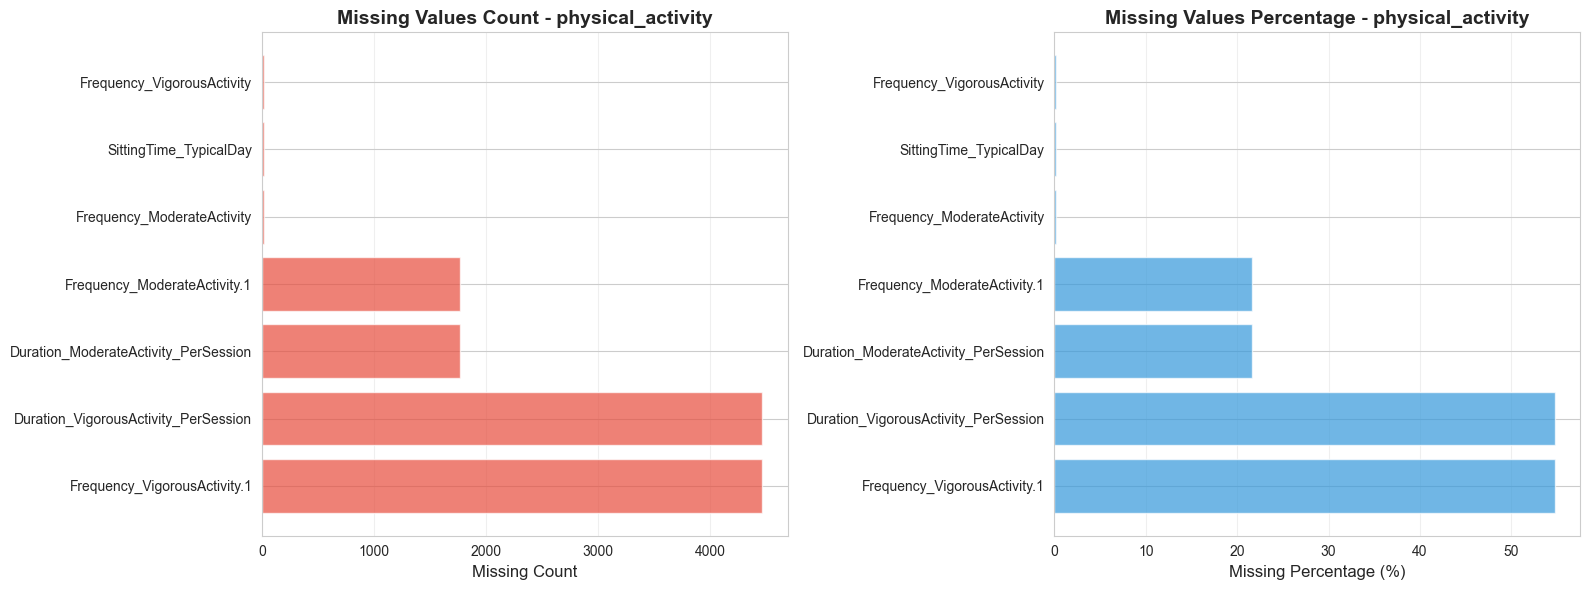




Dataset: physical_activity_youth
Total rows: 3109
Total columns: 3


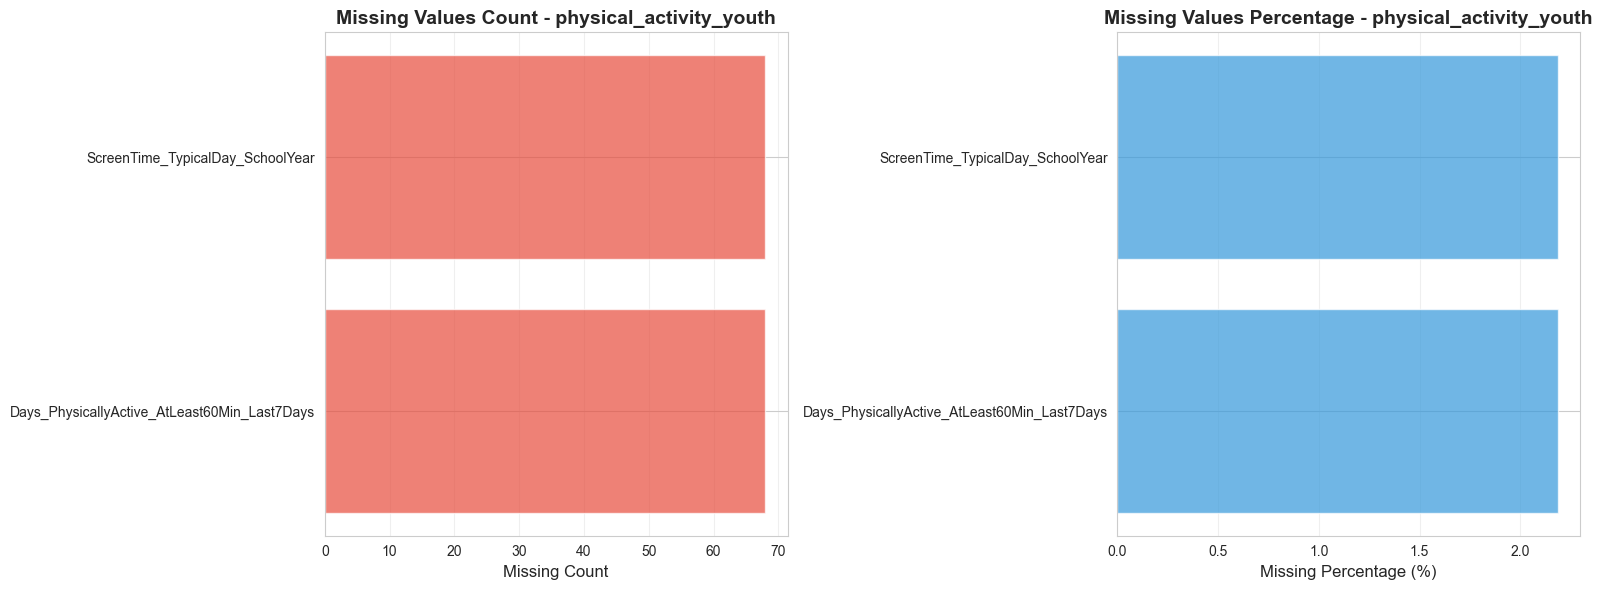




Dataset: sleep_disorders
Total rows: 8501
Total columns: 7


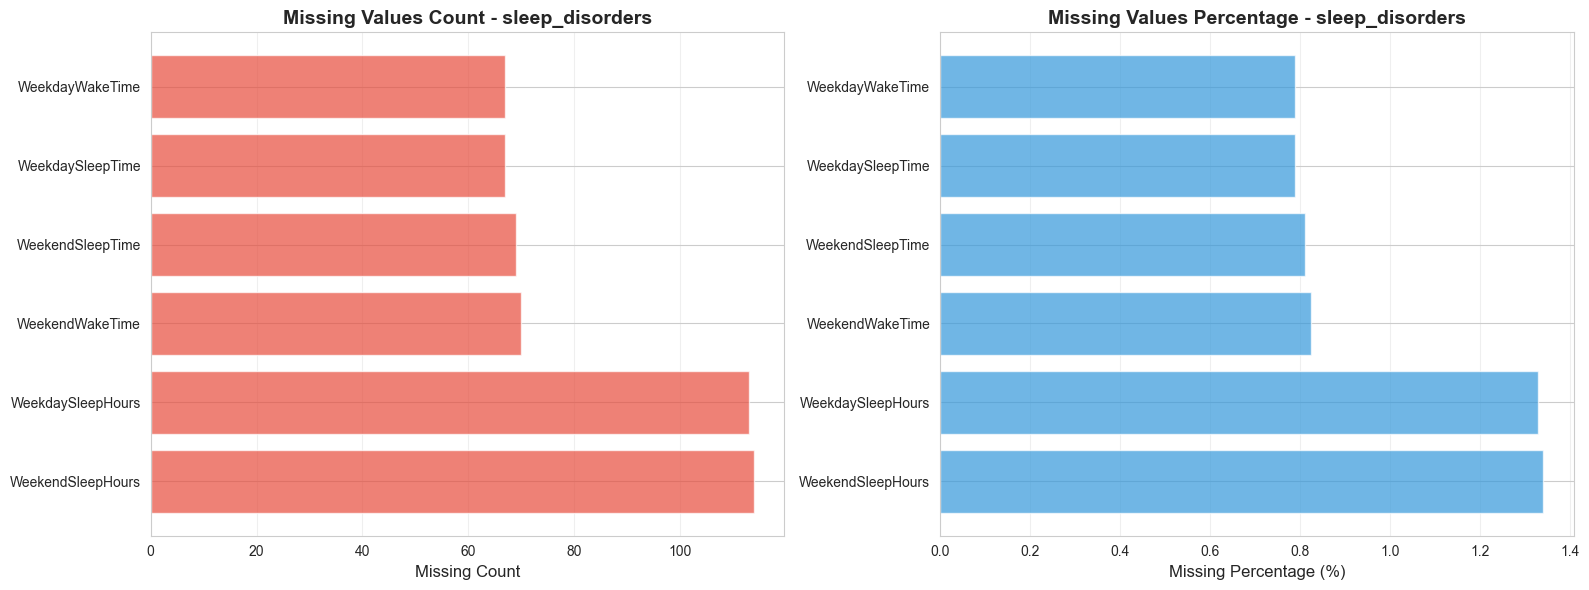




Dataset: smoking_cigarette_use
Total rows: 9015
Total columns: 9


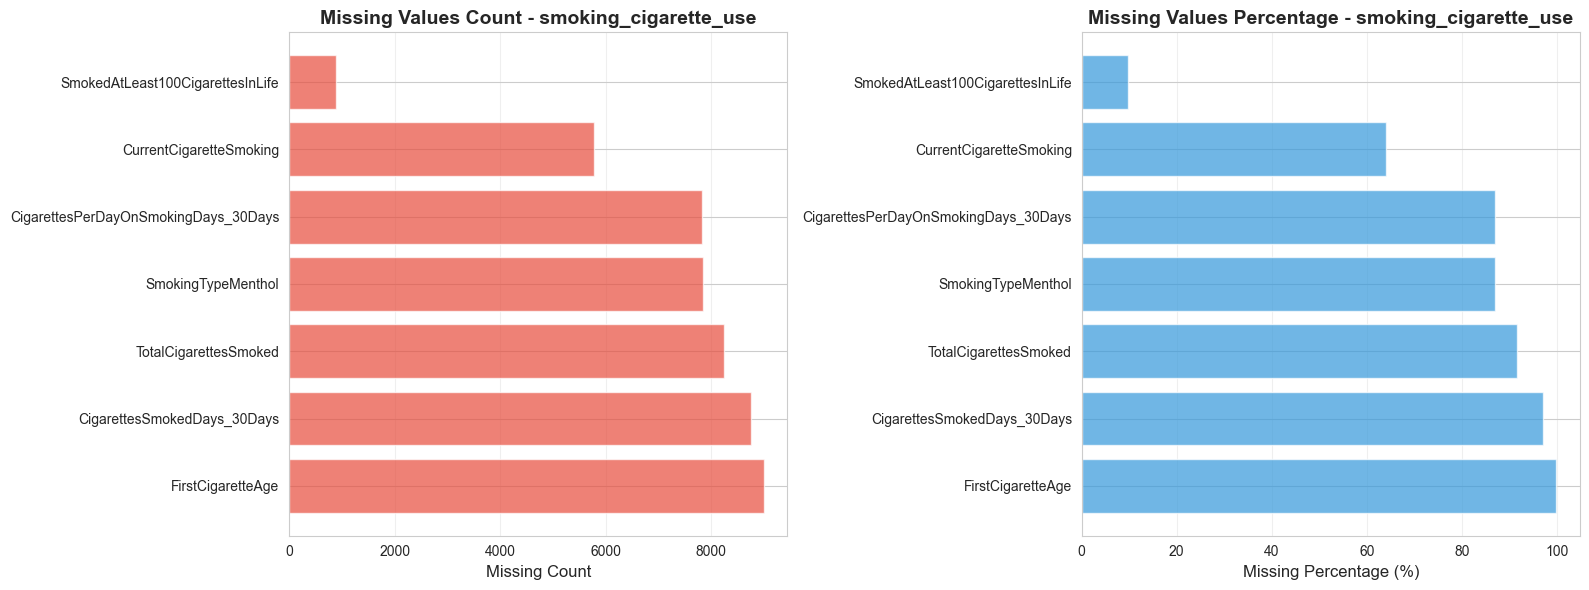




Dataset: smoking_household_smokers
Total rows: 11933
Total columns: 3


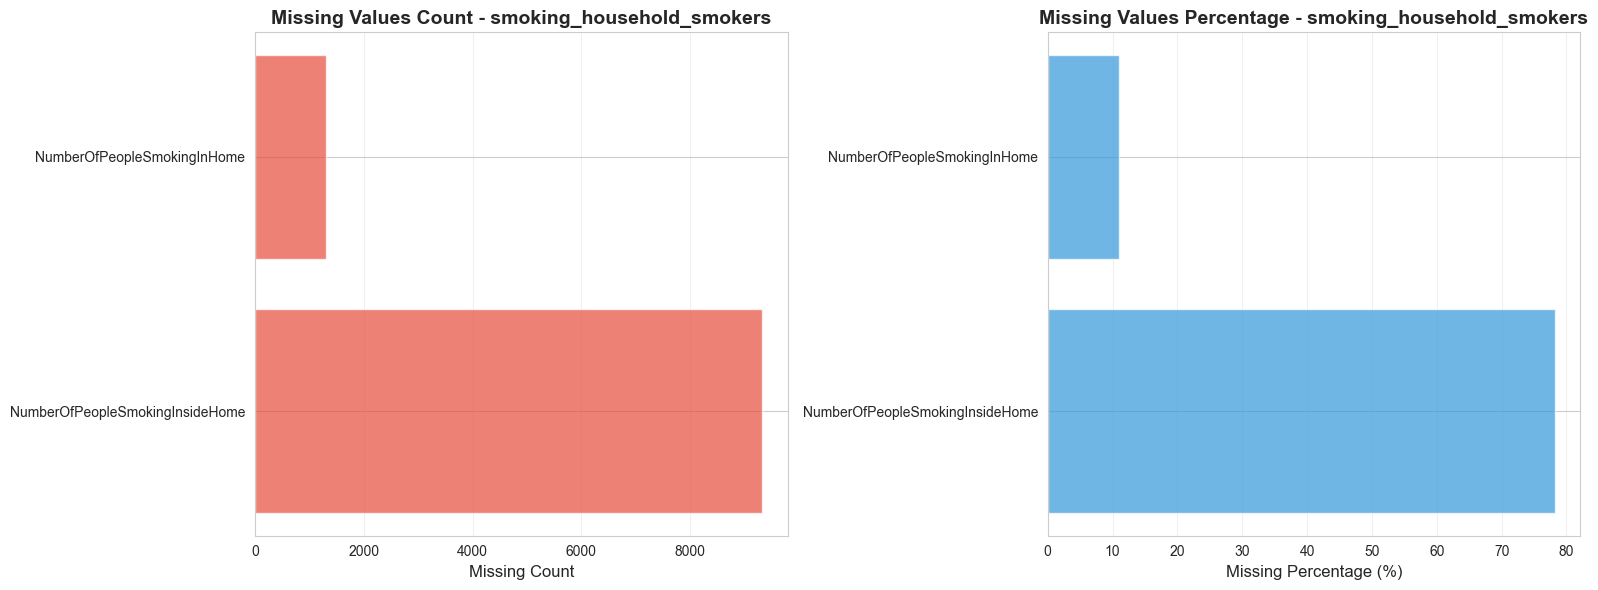




Dataset: smoking_recent_tobacco_use
Total rows: 7199
Total columns: 21


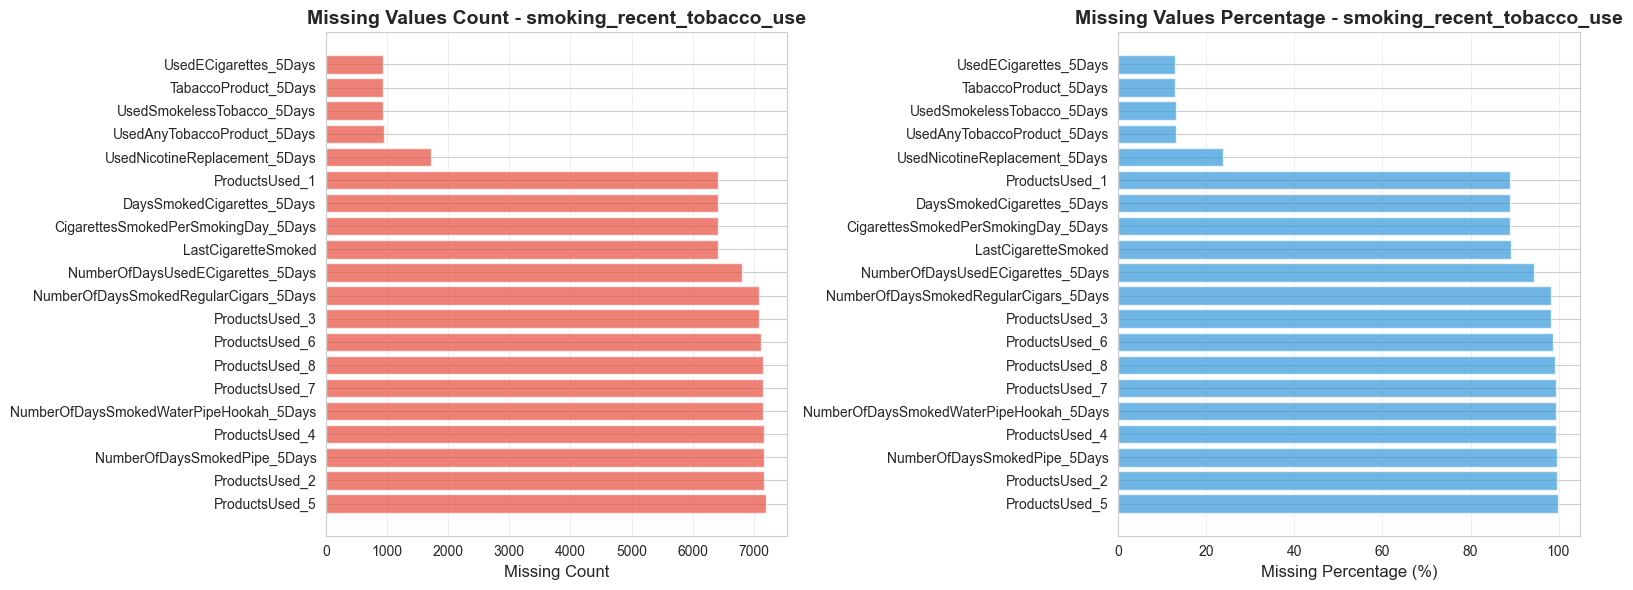




Dataset: audiometry
Total rows: 11744
Total columns: 14


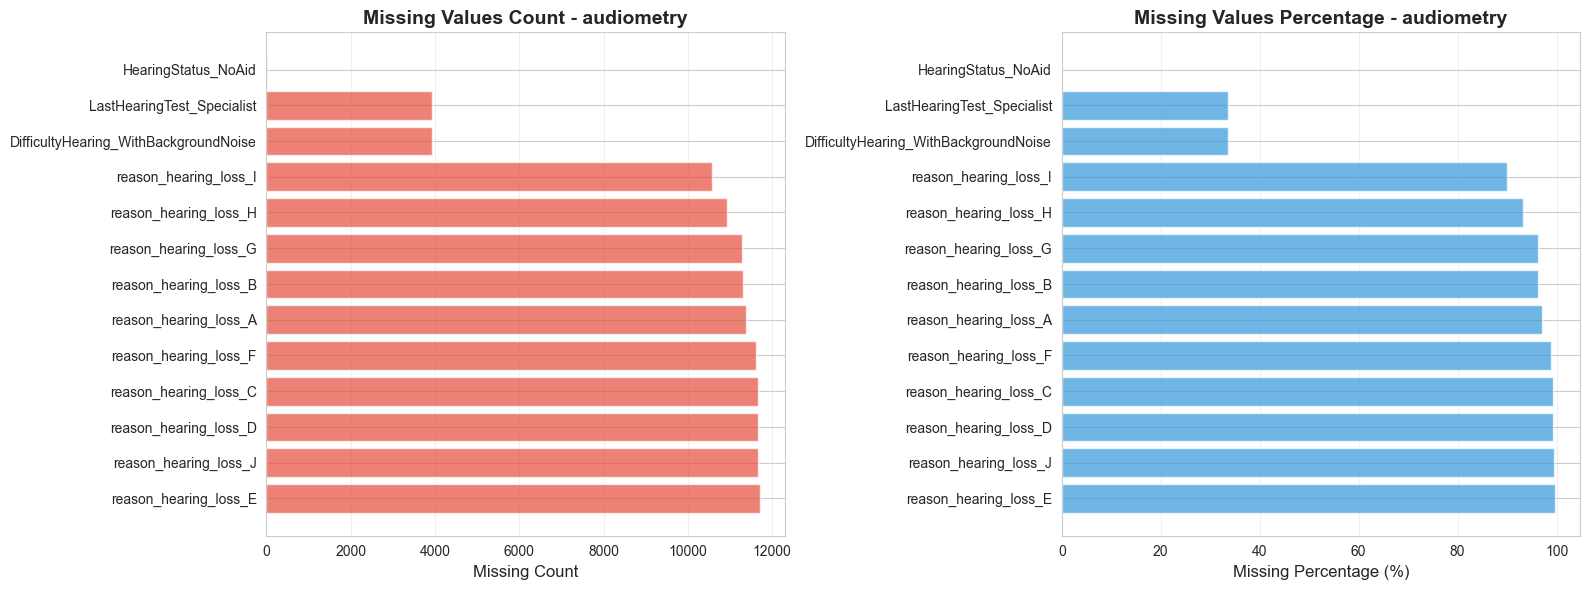




Dataset: functioning
Total rows: 10942
Total columns: 32


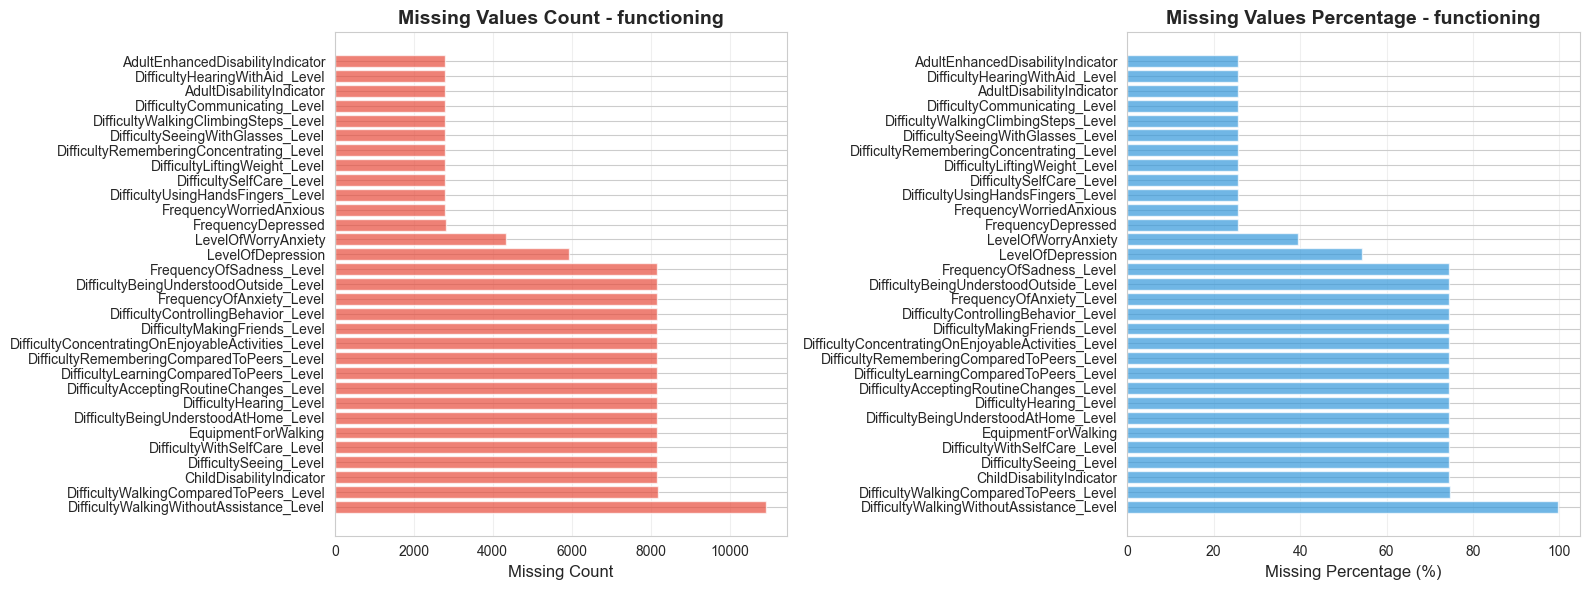




Dataset: hospital_utils
Total rows: 11933
Total columns: 6


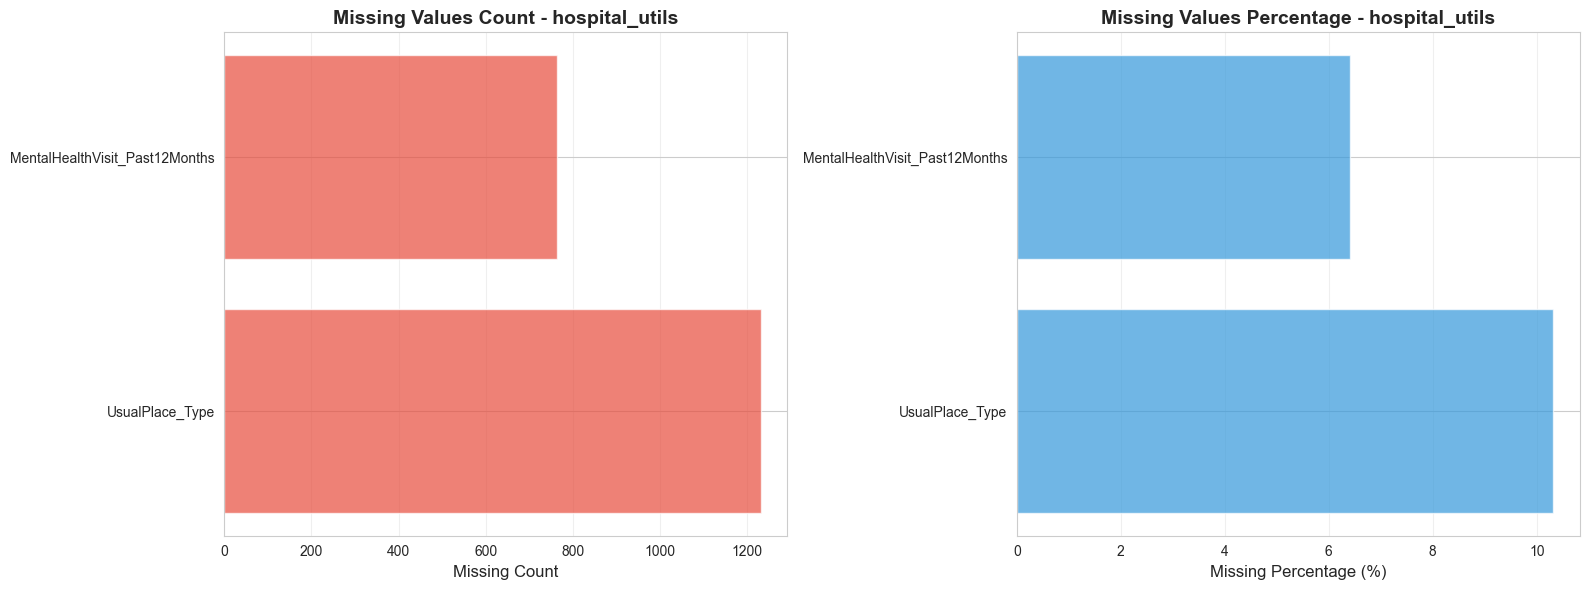




Dataset: diabetes
Total rows: 11744
Total columns: 9


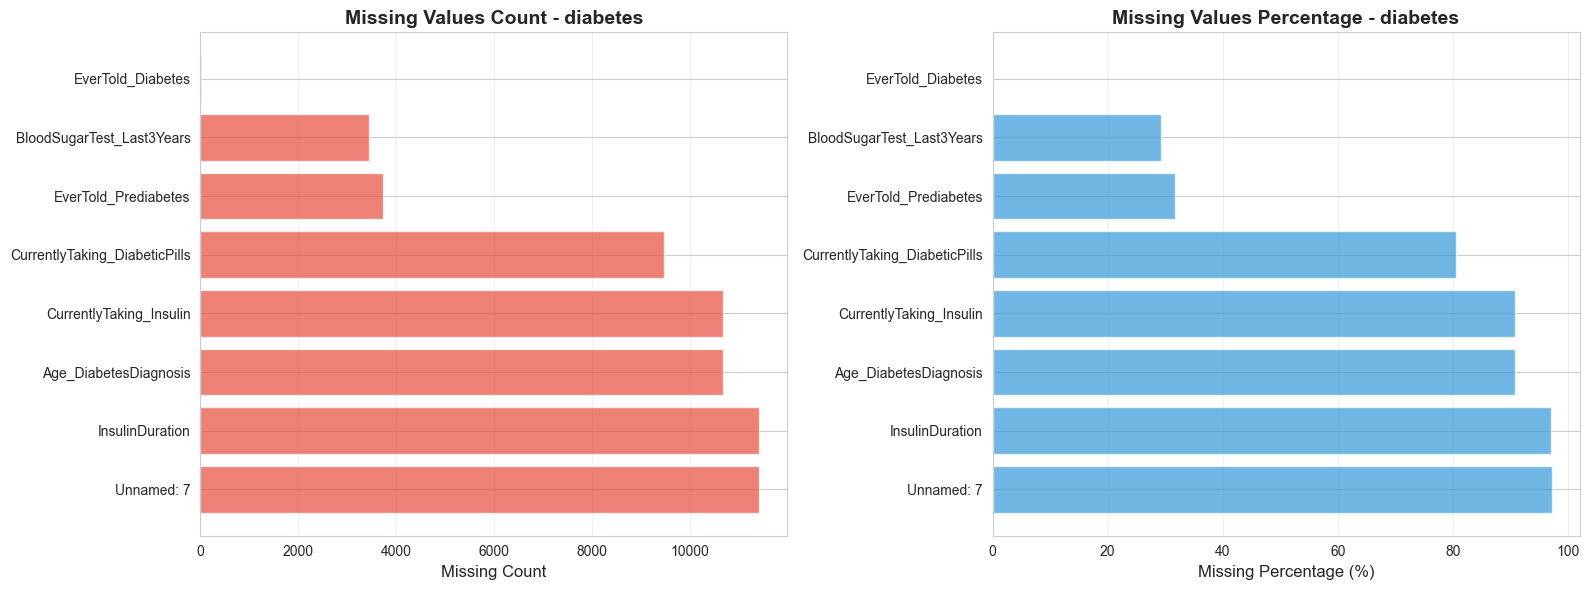

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"{'='*60}")
    print(f"Total rows: {len(df)}")
    print(f"Total columns: {len(df.columns)}")
    
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    missing_data = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Missing_Percent': missing_percent.values
    })
    
    missing_data_sorted = missing_data.sort_values('Missing_Count', ascending=False)
    
    if columns_with_missing > 0:
        missing_cols = missing_data_sorted[missing_data_sorted['Missing_Count'] > 0]
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        axes[0].barh(range(len(missing_cols)), missing_cols['Missing_Count'], 
                     color='#e74c3c', alpha=0.7)
        axes[0].set_yticks(range(len(missing_cols)))
        axes[0].set_yticklabels(missing_cols['Column'])
        axes[0].set_xlabel('Missing Count', fontsize=12)
        axes[0].set_title(f'Missing Values Count - {name}', fontsize=14, fontweight='bold')
        axes[0].grid(axis='x', alpha=0.3)
        
        axes[1].barh(range(len(missing_cols)), missing_cols['Missing_Percent'], 
                     color='#3498db', alpha=0.7)
        axes[1].set_yticks(range(len(missing_cols)))
        axes[1].set_yticklabels(missing_cols['Column'])
        axes[1].set_xlabel('Missing Percentage (%)', fontsize=12)
        axes[1].set_title(f'Missing Values Percentage - {name}', fontsize=14, fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n✓ No missing values in {name}!")
    
    print("\n" + "="*60 + "\n")

In [78]:
print(diabetes.count())
print(diabetes['EverTold_Diabetes'].value_counts())
print(diabetes['EverTold_Prediabetes'].value_counts())

mask = (diabetes['EverTold_Diabetes'] == 2.0) & (diabetes['EverTold_Prediabetes'] == 1.0)
print("Overlap count:", mask.sum())
print(diabetes.loc[mask, ['sequence_no','EverTold_Diabetes','EverTold_Prediabetes']].head())


sequence_no                      11744
EverTold_Diabetes                11740
Age_DiabetesDiagnosis             1081
EverTold_Prediabetes              8022
BloodSugarTest_Last3Years         8304
CurrentlyTaking_Insulin           1081
InsulinDuration                    343
Unnamed: 7                         332
CurrentlyTaking_DiabeticPills     2281
dtype: int64
EverTold_Diabetes
2.0    10371
1.0     1081
3.0      284
9.0        4
Name: count, dtype: int64
EverTold_Prediabetes
2.0    7089
1.0     918
9.0      15
Name: count, dtype: int64
Overlap count: 918
    sequence_no  EverTold_Diabetes  EverTold_Prediabetes
7      130385.0                2.0                   1.0
11     130389.0                2.0                   1.0
19     130397.0                2.0                   1.0
44     130422.0                2.0                   1.0
47     130425.0                2.0                   1.0


In [79]:
diabetes_clean = diabetes.dropna(subset=['EverTold_Diabetes'])

def assign_class(row):
    if row['EverTold_Diabetes'] == 1.0:
        return 0.0
    elif (row['EverTold_Diabetes'] == 2.0 and row['EverTold_Prediabetes'] == 1.0) :
        return 1.0
    elif row['EverTold_Diabetes'] == 3.0:
        return 1.0
    elif row['EverTold_Diabetes'] == 2.0:
        return 2.0
    else:
        return np.nan

diabetes_clean['diabetes_class'] = diabetes_clean.apply(assign_class, axis=1)

target_variable = diabetes_clean[['sequence_no', 'diabetes_class']].copy()

target_variable = target_variable.dropna(subset=['diabetes_class'])

target_variable.to_csv('main_focus/target_variable_diabetes.csv', index=False)




C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3273942243.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diabetes_clean['diabetes_class'] = diabetes_clean.apply(assign_class, axis=1)


In [80]:
print("Target Variable Distribution:")
print(target_variable['diabetes_class'].value_counts().sort_index())
print(f"\nTotal samples: {len(target_variable)}")
print(f"\nClass 0 (Diabetes): {(target_variable['diabetes_class'] == 0).sum()}")
print(f"Class 1 (Prediabetes): {(target_variable['diabetes_class'] == 1).sum()}")
print(f"Class 2 (No Diabetes): {(target_variable['diabetes_class'] == 2).sum()}")

print("\nFirst 10 rows:")
print(target_variable.head(10))



Target Variable Distribution:
diabetes_class
0.0    1081
1.0    1202
2.0    9453
Name: count, dtype: int64

Total samples: 11736

Class 0 (Diabetes): 1081
Class 1 (Prediabetes): 1202
Class 2 (No Diabetes): 9453

First 10 rows:
   sequence_no  diabetes_class
0     130378.0             2.0
1     130379.0             2.0
2     130380.0             0.0
3     130381.0             2.0
4     130382.0             2.0
5     130383.0             2.0
6     130384.0             2.0
7     130385.0             1.0
8     130386.0             2.0
9     130387.0             2.0


In [81]:
alcohol_use_clean = alcohol_use.dropna(subset=['EverHad_Alcohol'])
print(alcohol_use_clean.count())

sequence_no                                      5481
EverHad_Alcohol                                  5481
AlcoholConsumptionFrequency_12Months             4922
AverageDrinksPerDrinkingDay_12Months             4069
MoreThanSpecificNumberOfDrinksFrequency          4082
HeavyDrinkingWithinTwoHoursFrequency_12Months    2366
MoreThan8DrinksPerDay_12Months                   2362
DailyHeavyDrinkingHistory                        4901
OccasionsWithHeavyDrinking_30Days                2358
dtype: int64


In [82]:
alcohol_use_selected = alcohol_use_clean[['sequence_no', 'EverHad_Alcohol','AlcoholConsumptionFrequency_12Months','AverageDrinksPerDrinkingDay_12Months',
'MoreThanSpecificNumberOfDrinksFrequency','DailyHeavyDrinkingHistory']].copy()

print(alcohol_use_selected.count())

alcohol_use_selected.dropna(inplace=True)

print(alcohol_use_selected.count())


sequence_no                                5481
EverHad_Alcohol                            5481
AlcoholConsumptionFrequency_12Months       4922
AverageDrinksPerDrinkingDay_12Months       4069
MoreThanSpecificNumberOfDrinksFrequency    4082
DailyHeavyDrinkingHistory                  4901
dtype: int64
sequence_no                                4053
EverHad_Alcohol                            4053
AlcoholConsumptionFrequency_12Months       4053
AverageDrinksPerDrinkingDay_12Months       4053
MoreThanSpecificNumberOfDrinksFrequency    4053
DailyHeavyDrinkingHistory                  4053
dtype: int64


In [83]:
# Transform AlcoholConsumptionFrequency_12Months 

map = {
    0: 0,
    1: 365,
    2: 260,
    3: 156,
    4: 78,
    5: 52,
    6: 26,
    7: 12,
    8: 6,
    9: 4,
    10: 2,
}

alcohol_use_selected.loc[alcohol_use_selected['AlcoholConsumptionFrequency_12Months'] < 1e-5, 'AlcoholConsumptionFrequency_12Months'] = 0

alcohol_use_selected.loc[alcohol_use_selected['AlcoholConsumptionFrequency_12Months'].abs() < 1e-5, 'AlcoholConsumptionFrequency_12Months'] = 0

alcohol_use_selected['AlcoholConsumptionFrequency_12Months'] = alcohol_use_selected['AlcoholConsumptionFrequency_12Months'].map(map)

print(alcohol_use_selected['AlcoholConsumptionFrequency_12Months'].value_counts())

AlcoholConsumptionFrequency_12Months
26.0     570
2.0      538
4.0      513
78.0     478
156.0    457
52.0     415
12.0     357
260.0    301
6.0      260
365.0    160
Name: count, dtype: int64


In [84]:
combined_data = pd.merge(target_variable, alcohol_use_selected, on='sequence_no', how='inner')

print(combined_data.count())

sequence_no                                4052
diabetes_class                             4052
EverHad_Alcohol                            4052
AlcoholConsumptionFrequency_12Months       4048
AverageDrinksPerDrinkingDay_12Months       4052
MoreThanSpecificNumberOfDrinksFrequency    4052
DailyHeavyDrinkingHistory                  4052
dtype: int64


In [85]:
correlation_diabetes_class = combined_data.corr()['diabetes_class'].drop('diabetes_class')
print(correlation_diabetes_class)

sequence_no                               -0.018479
EverHad_Alcohol                            0.008653
AlcoholConsumptionFrequency_12Months       0.077353
AverageDrinksPerDrinkingDay_12Months      -0.024407
MoreThanSpecificNumberOfDrinksFrequency    0.017763
DailyHeavyDrinkingHistory                  0.025528
Name: diabetes_class, dtype: float64


In [86]:

bp_no_sentinels = blood_pressure_cholesterol[~blood_pressure_cholesterol.isin([9.0, 7.0]).any(axis=1)].copy()

blood_pressure_cholesterol_clean = bp_no_sentinels.dropna(subset=['EverTold_Hypertension', 'EverTold_HighCholesterol', 'CurrentlyTaking_CholesterolMedication'])

blood_pressure_cholesterol_use = blood_pressure_cholesterol_clean[['sequence_no', 'EverTold_Hypertension', 'EverTold_HighCholesterol', 'CurrentlyTaking_CholesterolMedication']].copy()

print(blood_pressure_cholesterol_use.count())
print(blood_pressure_cholesterol_use['EverTold_Hypertension'].value_counts(dropna=False))
print(blood_pressure_cholesterol_use['EverTold_HighCholesterol'].value_counts(dropna=False))
print(blood_pressure_cholesterol_use['CurrentlyTaking_CholesterolMedication'].value_counts(dropna=False))

sequence_no                              8381
EverTold_Hypertension                    8381
EverTold_HighCholesterol                 8381
CurrentlyTaking_CholesterolMedication    8381
dtype: int64
EverTold_Hypertension
2.0    5483
1.0    2898
Name: count, dtype: int64
EverTold_HighCholesterol
2.0    5319
1.0    3062
Name: count, dtype: int64
CurrentlyTaking_CholesterolMedication
2.0    6283
1.0    2098
Name: count, dtype: int64


In [87]:
# print(audiometry.count())
audiometry_clean = audiometry.dropna(subset=['HearingStatus_NoAid'])
print(audiometry_clean.count())

sequence_no                              11740
HearingStatus_NoAid                      11740
reason_hearing_loss_A                      358
reason_hearing_loss_B                      432
reason_hearing_loss_C                       87
reason_hearing_loss_D                       86
reason_hearing_loss_E                       30
reason_hearing_loss_F                      134
reason_hearing_loss_G                      450
reason_hearing_loss_H                      806
reason_hearing_loss_I                     1179
reason_hearing_loss_J                       66
LastHearingTest_Specialist                7807
DifficultyHearing_WithBackgroundNoise     7804
dtype: int64


In [88]:
print(audiometry_clean['HearingStatus_NoAid'].value_counts()) 
print(audiometry_clean['reason_hearing_loss_A'].value_counts())
print(audiometry_clean['reason_hearing_loss_B'].value_counts())
print(audiometry_clean['reason_hearing_loss_C'].value_counts())
print(audiometry_clean['reason_hearing_loss_D'].value_counts())
print(audiometry_clean['reason_hearing_loss_E'].value_counts())
print(audiometry_clean['reason_hearing_loss_F'].value_counts())
print(audiometry_clean['reason_hearing_loss_G'].value_counts())
print(audiometry_clean['reason_hearing_loss_H'].value_counts())
print(audiometry_clean['reason_hearing_loss_I'].value_counts())
print(audiometry_clean['reason_hearing_loss_J'].value_counts())
print(audiometry_clean['LastHearingTest_Specialist'].value_counts())
print(audiometry_clean['DifficultyHearing_WithBackgroundNoise'].value_counts())

HearingStatus_NoAid
1.0     5201
2.0     4217
3.0     1354
4.0      645
5.0      284
6.0       36
99.0       2
77.0       1
Name: count, dtype: int64
reason_hearing_loss_A
1.0     276
99.0     82
Name: count, dtype: int64
reason_hearing_loss_B
2.0    432
Name: count, dtype: int64
reason_hearing_loss_C
3.0    87
Name: count, dtype: int64
reason_hearing_loss_D
4.0    86
Name: count, dtype: int64
reason_hearing_loss_E
5.0    30
Name: count, dtype: int64
reason_hearing_loss_F
6.0    134
Name: count, dtype: int64
reason_hearing_loss_G
7.0    450
Name: count, dtype: int64
reason_hearing_loss_H
8.0    806
Name: count, dtype: int64
reason_hearing_loss_I
9.0    1179
Name: count, dtype: int64
reason_hearing_loss_J
10.0    66
Name: count, dtype: int64
LastHearingTest_Specialist
4.0    2561
5.0    1963
2.0    1378
3.0     969
1.0     717
9.0     218
7.0       1
Name: count, dtype: int64
DifficultyHearing_WithBackgroundNoise
4.0    2834
5.0    2444
3.0    1315
2.0     696
1.0     494
9.0      19
7.

In [89]:
# merge all reason hearing col
audiometry_clean['reason_hearing_loss_combined'] = audiometry_clean[['reason_hearing_loss_A', 'reason_hearing_loss_B', 'reason_hearing_loss_C',
       'reason_hearing_loss_D', 'reason_hearing_loss_E', 'reason_hearing_loss_F',
       'reason_hearing_loss_G', 'reason_hearing_loss_H', 'reason_hearing_loss_I',
       'reason_hearing_loss_J']].sum(axis=1)    
print(audiometry_clean['reason_hearing_loss_combined'].value_counts())

audiometry_selected = audiometry_clean[['sequence_no', 'HearingStatus_NoAid', 'reason_hearing_loss_combined',
       'LastHearingTest_Specialist', 'DifficultyHearing_WithBackgroundNoise']].copy()

print(audiometry_selected.count())

reason_hearing_loss_combined
0.0     9422
9.0      590
8.0      254
2.0      186
17.0     186
10.0     145
15.0     120
1.0       96
24.0      94
7.0       92
99.0      82
16.0      68
11.0      55
3.0       53
6.0       50
12.0      31
18.0      31
4.0       21
14.0      18
21.0      18
5.0       18
26.0      17
19.0      17
13.0      11
30.0      11
22.0      11
23.0      10
20.0      10
25.0       8
27.0       5
28.0       3
29.0       3
40.0       1
36.0       1
35.0       1
33.0       1
Name: count, dtype: int64
sequence_no                              11740
HearingStatus_NoAid                      11740
reason_hearing_loss_combined             11740
LastHearingTest_Specialist                7807
DifficultyHearing_WithBackgroundNoise     7804
dtype: int64


C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\4010492881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  audiometry_clean['reason_hearing_loss_combined'] = audiometry_clean[['reason_hearing_loss_A', 'reason_hearing_loss_B', 'reason_hearing_loss_C',


C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3878988110.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_diabetes_class_audio.sort_values(ascending=False).values,


DifficultyHearing_WithBackgroundNoise    0.133020
LastHearingTest_Specialist               0.032165
reason_hearing_loss_combined            -0.130896
HearingStatus_NoAid                     -0.134300
Name: diabetes_class, dtype: float64
DifficultyHearing_WithBackgroundNoise    0.069672
LastHearingTest_Specialist               0.014425
Name: EverTold_Diabetes, dtype: float64
DifficultyHearing_WithBackgroundNoise    0.063915
LastHearingTest_Specialist               0.017588
Name: EverTold_Prediabetes, dtype: float64


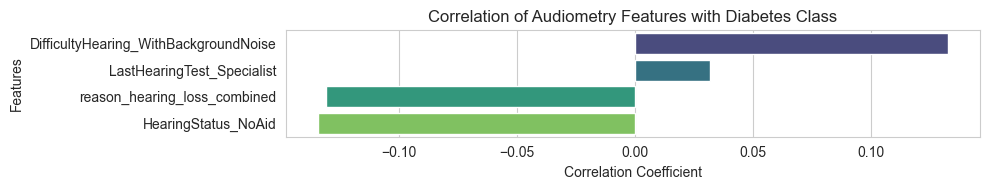

C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3878988110.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_diabetes_audio.sort_values(ascending=False).values,


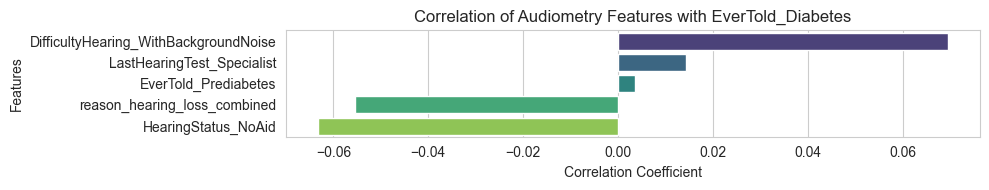

C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3878988110.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_prediabetes_audio.sort_values(ascending=False).values,


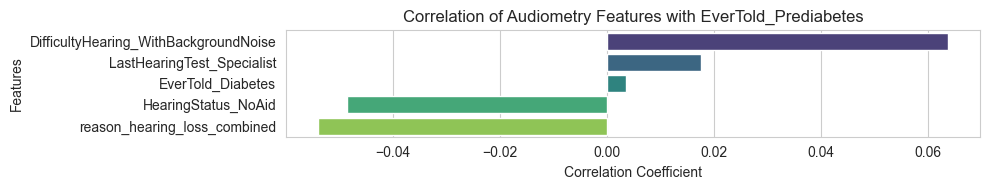

In [90]:
audio_target_merged = pd.merge(target_variable, audiometry_selected, on='sequence_no', how='inner')

correlation_diabetes_class_audio = audio_target_merged.corr()['diabetes_class'].drop(['diabetes_class','sequence_no'])
print(correlation_diabetes_class_audio.sort_values(ascending=False))


audio_diabetes_merged = pd.merge(diabetes[['sequence_no','EverTold_Diabetes','EverTold_Prediabetes']], audiometry_selected, on='sequence_no', how='inner')

correlation_diabetes_audio = audio_diabetes_merged.corr()['EverTold_Diabetes'].drop(['EverTold_Diabetes','sequence_no'])
correlation_prediabetes_audio = audio_diabetes_merged.corr()['EverTold_Prediabetes'].drop(['EverTold_Prediabetes','sequence_no'])
print(correlation_diabetes_audio.sort_values(ascending=False)[:2])
print(correlation_prediabetes_audio.sort_values(ascending=False)[:2])

plt.figure(figsize=(10, 2))
sns.barplot(x=correlation_diabetes_class_audio.sort_values(ascending=False).values,
            y=correlation_diabetes_class_audio.sort_values(ascending=False).index, palette='viridis')
plt.title('Correlation of Audiometry Features with Diabetes Class')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 2))
sns.barplot(x=correlation_diabetes_audio.sort_values(ascending=False).values,
            y=correlation_diabetes_audio.sort_values(ascending=False).index, palette='viridis')
plt.title('Correlation of Audiometry Features with EverTold_Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 2))
sns.barplot(x=correlation_prediabetes_audio.sort_values(ascending=False).values,
            y=correlation_prediabetes_audio.sort_values(ascending=False).index, palette='viridis')
plt.title('Correlation of Audiometry Features with EverTold_Prediabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\2741642989.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_diabetes_class_functioning.sort_values(ascending=False).values, y=correlation_diabetes_class_functioning.sort_values(ascending=False).index, palette='viridis')


sequence_no                                 10942
AdultEnhancedDisabilityIndicator             8143
DifficultyHearingWithAid_Level               8143
AdultDisabilityIndicator                     8143
DifficultyCommunicating_Level                8142
DifficultyWalkingClimbingSteps_Level         8142
FrequencyDepressed                           8138
FrequencyWorriedAnxious                      8140
DifficultyUsingHandsFingers_Level            8141
DifficultySelfCare_Level                     8141
DifficultyLiftingWeight_Level                8141
DifficultyRememberingConcentrating_Level     8142
DifficultySeeingWithGlasses_Level            8142
dtype: int64
DifficultyWalkingClimbingSteps_Level        0.295226
DifficultyUsingHandsFingers_Level           0.199678
AdultDisabilityIndicator                    0.190206
AdultEnhancedDisabilityIndicator            0.179432
DifficultySeeingWithGlasses_Level           0.144426
DifficultyLiftingWeight_Level               0.124740
DifficultySelfCare_

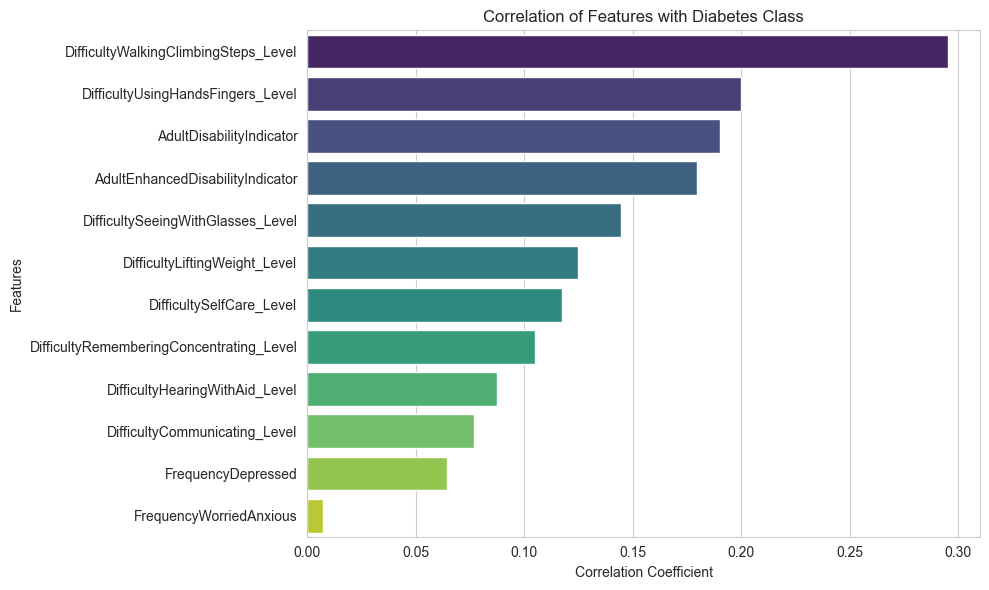

In [91]:
functioning_clean = functioning.dropna(subset=['AdultEnhancedDisabilityIndicator',
    'DifficultyHearingWithAid_Level',
    'AdultDisabilityIndicator',
    'DifficultyCommunicating_Level',
    'DifficultyWalkingClimbingSteps_Level',
    'FrequencyDepressed',
    'FrequencyWorriedAnxious',
    'DifficultyUsingHandsFingers_Level',
    'DifficultySelfCare_Level',
    'DifficultyLiftingWeight_Level',
    'DifficultyRememberingConcentrating_Level',
    'DifficultySeeingWithGlasses_Level']).copy()
    
functioning_selected = functioning[['sequence_no','AdultEnhancedDisabilityIndicator',
    'DifficultyHearingWithAid_Level',
    'AdultDisabilityIndicator',
    'DifficultyCommunicating_Level',
    'DifficultyWalkingClimbingSteps_Level',
    'FrequencyDepressed',
    'FrequencyWorriedAnxious',
    'DifficultyUsingHandsFingers_Level',
    'DifficultySelfCare_Level',
    'DifficultyLiftingWeight_Level',
    'DifficultyRememberingConcentrating_Level',
    'DifficultySeeingWithGlasses_Level']].copy()

print(functioning_selected.count())

functioning_diabetes_class = pd.merge(target_variable, functioning_selected, on='sequence_no', how='inner')

correlation_diabetes_class_functioning = functioning_diabetes_class.corr()['diabetes_class'].drop(['diabetes_class','sequence_no'])
correlation_diabetes_class_functioning = correlation_diabetes_class_functioning.abs()
print(correlation_diabetes_class_functioning.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_diabetes_class_functioning.sort_values(ascending=False).values, y=correlation_diabetes_class_functioning.sort_values(ascending=False).index, palette='viridis')
plt.title('Correlation of Features with Diabetes Class')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3490536003.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True)
C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3490536003.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True)
C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3490536003.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True)
C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\3490536003.py:35: MatplotlibDe

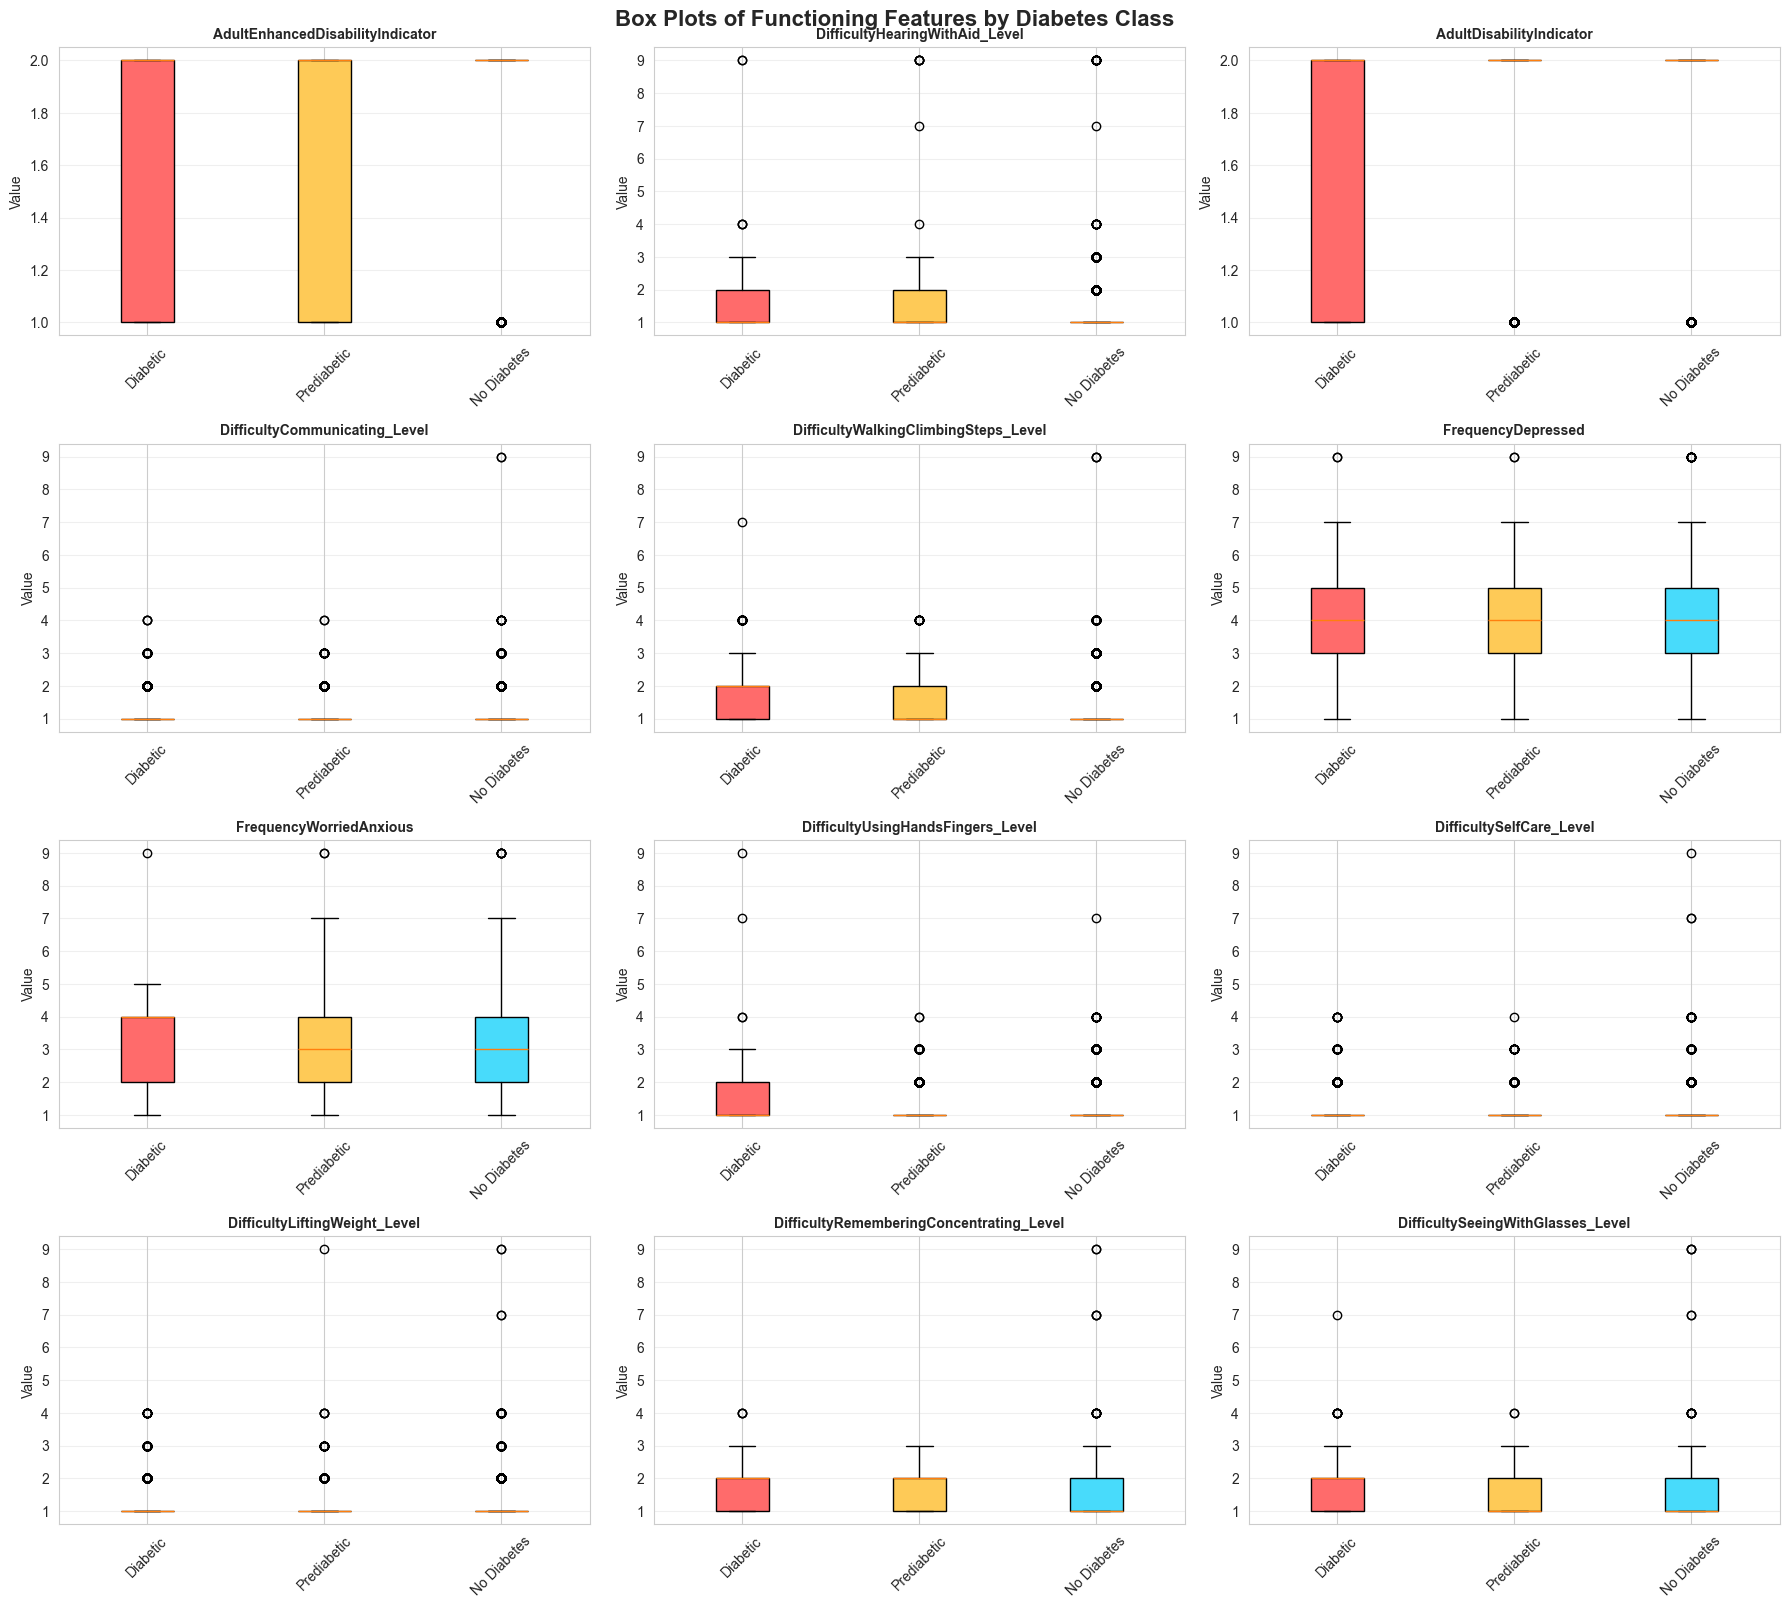


SUMMARY STATISTICS BY DIABETES CLASS

AdultEnhancedDisabilityIndicator:
--------------------------------------------------------------------------------

Diabetic:
  Count: 1072
  Mean: 1.5840
  Median: 2.0000
  Std Dev: 0.4931
  Min: 1.0000
  Max: 2.0000

Prediabetic:
  Count: 1156
  Mean: 1.7258
  Median: 2.0000
  Std Dev: 0.4463
  Min: 1.0000
  Max: 2.0000

No Diabetes:
  Count: 5913
  Mean: 1.8077
  Median: 2.0000
  Std Dev: 0.3941
  Min: 1.0000
  Max: 2.0000

DifficultyHearingWithAid_Level:
--------------------------------------------------------------------------------

Diabetic:
  Count: 1072
  Mean: 1.4198
  Median: 1.0000
  Std Dev: 0.6962
  Min: 1.0000
  Max: 9.0000

Prediabetic:
  Count: 1156
  Mean: 1.3659
  Median: 1.0000
  Std Dev: 0.7561
  Min: 1.0000
  Max: 9.0000

No Diabetes:
  Count: 5913
  Mean: 1.2630
  Median: 1.0000
  Std Dev: 0.6422
  Min: 1.0000
  Max: 9.0000

AdultDisabilityIndicator:
---------------------------------------------------------------------------

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

functioning_with_class = pd.merge(functioning_selected, target_variable, on='sequence_no', how='inner')

plot_data = functioning_with_class.drop('sequence_no', axis=1)

feature_cols = [col for col in plot_data.columns if col != 'diabetes_class']

n_features = len(feature_cols)
n_cols = 3  # Number of columns in subplot grid
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

class_labels = {0.0: 'Diabetic', 1.0: 'Prediabetic', 2.0: 'No Diabetes'}

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_by_class = []
    labels = []
    
    for diabetes_class in [0.0, 1.0, 2.0]:
        class_data = plot_data[plot_data['diabetes_class'] == diabetes_class][feature].dropna()
        if len(class_data) > 0:
            data_by_class.append(class_data)
            labels.append(class_labels[diabetes_class])
    
    # Create box plot
    bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True)
    
    # Color the boxes
    colors = ['#ff6b6b', '#feca57', '#48dbfb']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
    
    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Box Plots of Functioning Features by Diabetes Class', 
             fontsize=16, fontweight='bold', y=1.002)
plt.show()

# Also create a summary statistics table
print("\n" + "="*80)
print("SUMMARY STATISTICS BY DIABETES CLASS")
print("="*80)

for feature in feature_cols:
    print(f"\n{feature}:")
    print("-" * 80)
    
    for diabetes_class in [0.0, 1.0, 2.0]:
        class_data = plot_data[plot_data['diabetes_class'] == diabetes_class][feature].dropna()
        
        if len(class_data) > 0:
            print(f"\n{class_labels[diabetes_class]}:")
            print(f"  Count: {len(class_data)}")
            print(f"  Mean: {class_data.mean():.4f}")
            print(f"  Median: {class_data.median():.4f}")
            print(f"  Std Dev: {class_data.std():.4f}")
            print(f"  Min: {class_data.min():.4f}")
            print(f"  Max: {class_data.max():.4f}")

sequence_no                           11933
GeneralHealth_Status                  11933
HasUsualPlace_ForCare                 11933
UsualPlace_Type                       10702
TelehealthAppointment_Past12Months    11933
MentalHealthVisit_Past12Months        11169
dtype: int64
TelehealthAppointment_Past12Months    0.100483
HasUsualPlace_ForCare                 0.064826
MentalHealthVisit_Past12Months        0.021897
UsualPlace_Type                      -0.026748
GeneralHealth_Status                 -0.355784
Name: diabetes_class, dtype: float64


C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\800808019.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_diabetes_class_hospital.sort_values(ascending=False).values


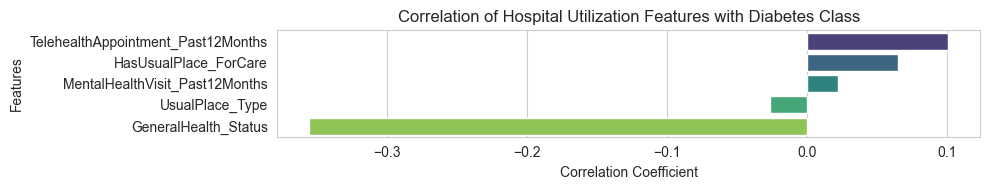

In [93]:
print(hospital_utils.count())

hospital_utils_diabetes_class = pd.merge(target_variable, hospital_utils, on='sequence_no', how='inner')

correlation_diabetes_class_hospital = hospital_utils_diabetes_class.corr()['diabetes_class'].drop(['diabetes_class','sequence_no'])
print(correlation_diabetes_class_hospital.sort_values(ascending=False))
plt.figure(figsize=(10, 2))
sns.barplot(x=correlation_diabetes_class_hospital.sort_values(ascending=False).values
, y=correlation_diabetes_class_hospital.sort_values(ascending=False).index, palette='viridis')
plt.title('Correlation of Hospital Utilization Features with Diabetes Class')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\1018940067.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette='viridis')


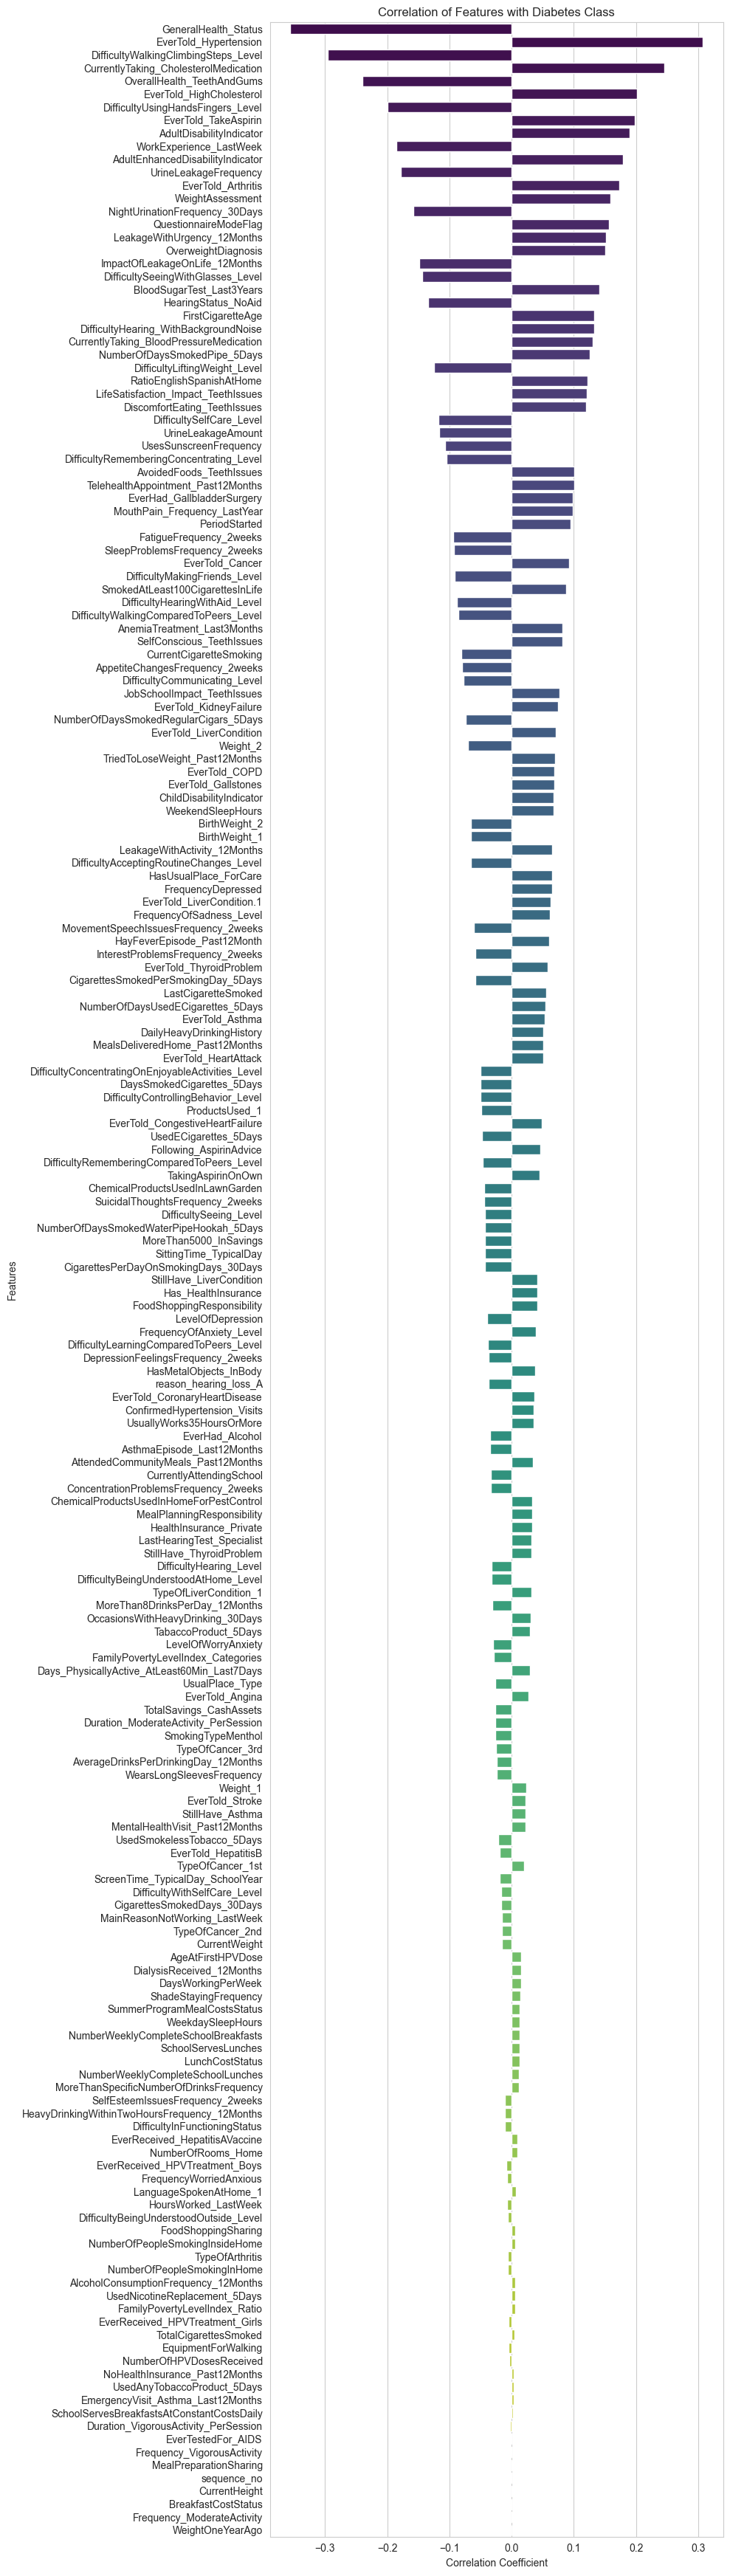

GeneralHealth_Status                       -0.355784
EverTold_Hypertension                       0.307340
DifficultyWalkingClimbingSteps_Level       -0.295226
CurrentlyTaking_CholesterolMedication       0.245945
OverallHealth_TeethAndGums                 -0.239575
EverTold_HighCholesterol                    0.201280
DifficultyUsingHandsFingers_Level          -0.199678
EverTold_TakeAspirin                        0.197594
AdultDisabilityIndicator                    0.190206
WorkExperience_LastWeek                    -0.184988
AdultEnhancedDisabilityIndicator            0.179432
UrineLeakageFrequency                      -0.178648
EverTold_Arthritis                          0.173100
WeightAssessment                            0.158703
NightUrinationFrequency_30Days             -0.157638
QuestionnaireModeFlag                       0.156113
LeakageWithUrgency_12Months                 0.152060
OverweightDiagnosis                         0.150755
ImpactOfLeakageOnLife_12Months             -0.

C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\1018940067.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data2.values, y=data2.index, palette='viridis')


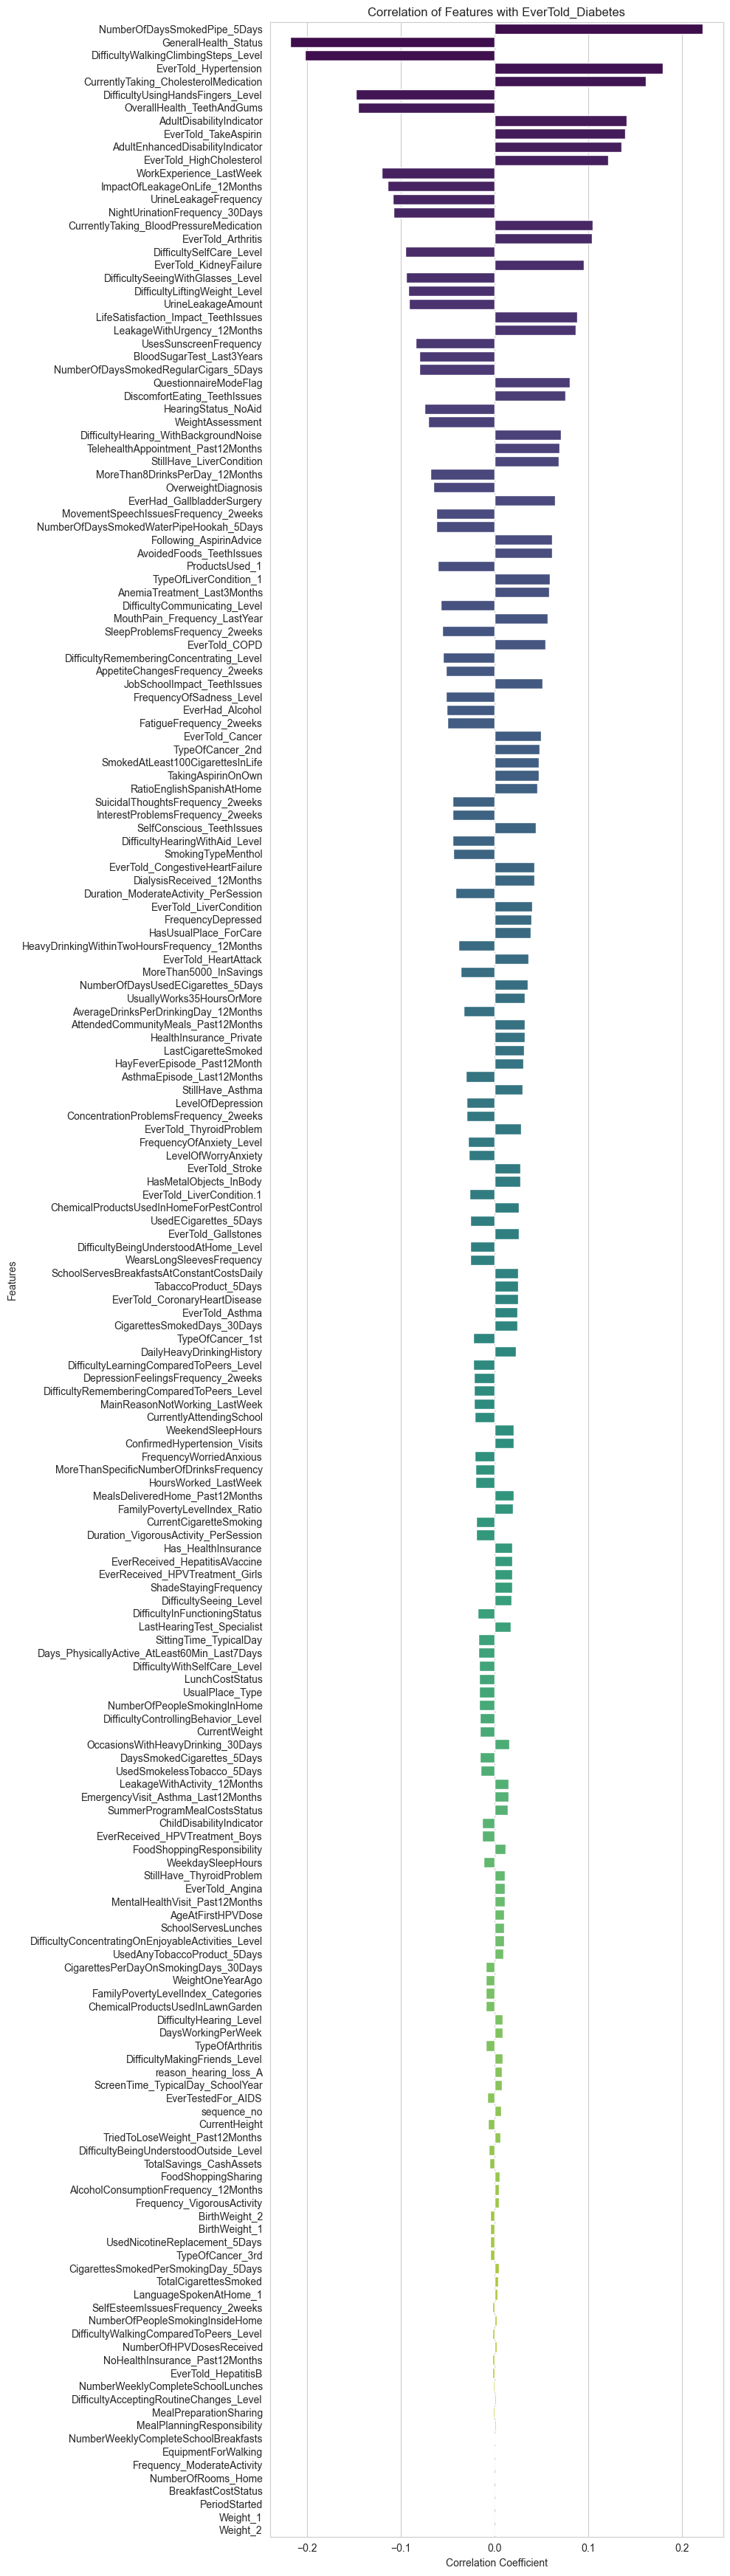

NumberOfDaysSmokedPipe_5Days                0.222394
GeneralHealth_Status                       -0.217821
DifficultyWalkingClimbingSteps_Level       -0.202310
EverTold_Hypertension                       0.180012
CurrentlyTaking_CholesterolMedication       0.161647
DifficultyUsingHandsFingers_Level          -0.148231
OverallHealth_TeethAndGums                 -0.145851
AdultDisabilityIndicator                    0.140889
EverTold_TakeAspirin                        0.139905
AdultEnhancedDisabilityIndicator            0.135746
EverTold_HighCholesterol                    0.121749
WorkExperience_LastWeek                    -0.120142
ImpactOfLeakageOnLife_12Months             -0.113842
UrineLeakageFrequency                      -0.108497
NightUrinationFrequency_30Days             -0.107934
CurrentlyTaking_BloodPressureMedication     0.104832
EverTold_Arthritis                          0.104008
DifficultySelfCare_Level                   -0.095527
EverTold_KidneyFailure                      0.

C:\Users\Yajesh\AppData\Local\Temp\ipykernel_159340\1018940067.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data3.values, y=data3.index, palette='viridis')


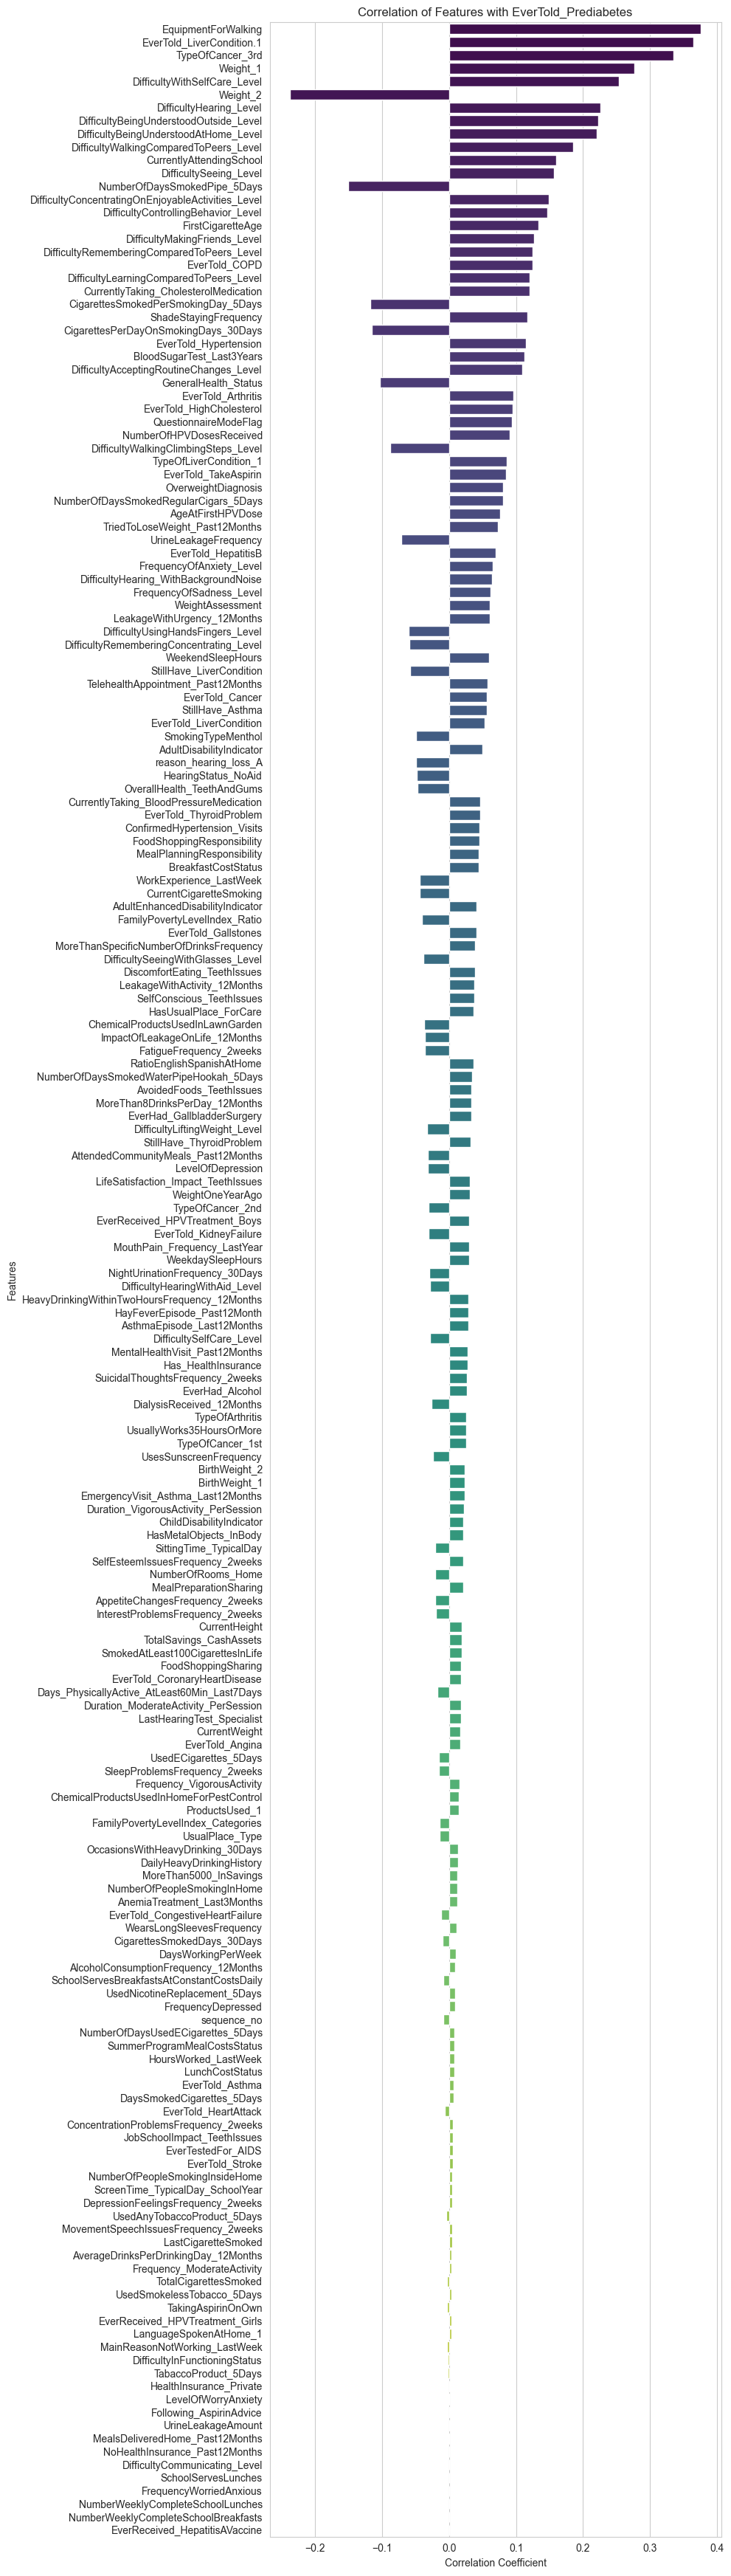

EquipmentForWalking                                   0.375698
EverTold_LiverCondition.1                             0.364946
TypeOfCancer_3rd                                      0.335054
Weight_1                                              0.276399
DifficultyWithSelfCare_Level                          0.253741
Weight_2                                             -0.237508
DifficultyHearing_Level                               0.226397
DifficultyBeingUnderstoodOutside_Level                0.222906
DifficultyBeingUnderstoodAtHome_Level                 0.220083
DifficultyWalkingComparedToPeers_Level                0.185511
CurrentlyAttendingSchool                              0.160106
DifficultySeeing_Level                                0.156078
NumberOfDaysSmokedPipe_5Days                         -0.150329
DifficultyConcentratingOnEnjoyableActivities_Level    0.148747
DifficultyControllingBehavior_Level                   0.146664
FirstCigaretteAge                                     0

In [99]:
_combined_data = pd.read_csv('data/combined_data.csv')
_combined_data = _combined_data.select_dtypes(include=[np.number])
combined_data = _combined_data.merge(target_variable, on='sequence_no', how='inner')
# combined_data2 = combined_data.merge(diabetes[['sequence_no','EverTold_Diabetes','EverTold_Prediabetes']], on='sequence_no', how='inner')
corr_matrix = combined_data.corr()
# corr_matrix2 = combined_data2.corr()
_data = corr_matrix['diabetes_class'].sort_values(ascending=False, key=abs)
_data2 = corr_matrix['EverTold_Diabetes'].sort_values(ascending=False, key=abs)
_data3 = corr_matrix['EverTold_Prediabetes'].sort_values(ascending=False, key=abs)

data = _data.drop(['diabetes_class','PrescriptionMeds_Count_Last30Days','EverTold_Prediabetes','EverTold_Diabetes','CurrentlyTaking_DiabeticPills',
           'PrescriptionMedication_Used_Last30Days','ProductsUsed_4'])

data2 = _data2.drop(['diabetes_class','PrescriptionMeds_Count_Last30Days','EverTold_Prediabetes','EverTold_Diabetes','CurrentlyTaking_DiabeticPills',
           'PrescriptionMedication_Used_Last30Days','ProductsUsed_4'])

data3 = _data3.drop(['diabetes_class','PrescriptionMeds_Count_Last30Days','EverTold_Prediabetes','EverTold_Diabetes','CurrentlyTaking_DiabeticPills',
              'PrescriptionMedication_Used_Last30Days','ProductsUsed_4'])




# data = data>= 0.00
data = data[abs(data) >= 0.00]
# data = abs(data)
plt.figure(figsize=(10, 35))
sns.barplot(x=data.values, y=data.index, palette='viridis')
plt.title('Correlation of Features with Diabetes Class')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print(data[:50])

data2 = data2[abs(data2) >= 0.00]
# data2 = abs(data2)
plt.figure(figsize=(10, 35))
sns.barplot(x=data2.values, y=data2.index, palette='viridis')
plt.title('Correlation of Features with EverTold_Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
print(data2[:50])
data3 = data3[abs(data3) >= 0.00]
# data3 = abs(data3)
plt.figure(figsize=(10, 35))
sns.barplot(x=data3.values, y=data3.index, palette='viridis')
plt.title('Correlation of Features with EverTold_Prediabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
print(data3[:50])





In [ ]:
cardiovascular_cluster = [
    'EverTold_Hypertension',
    'EverTold_HighCholesterol',
    'EverTold_TakeAspirin',
    'CurrentlyTaking_CholesterolMedication',
    'CurrentlyTaking_BloodPressureMedication',
]

cardiovascular_data = _combined_data[ ['sequence_no'] + cardiovascular_cluster]

functional_assessment_cluster = [
    'DifficultyWalkingClimbingSteps_Level',
    'DifficultyUsingHandsFingers_Level',
    'DifficultySeeingWithGlasses_Level',
    'DifficultyLiftingWeight_Level',
    'DifficultySelfCare_Level',
    'DifficultyRememberingConcentrating_Level',
    'DifficultyWalkingComparedToPeers_Level',
    'AdultDisabilityIndicator',
    'AdultEnhancedDisabilityIndicator',
]

functional_assessment_data = _combined_data[ ['sequence_no'] + functional_assessment_cluster]

urinary_health_cluster = [
    'UrineLeakageFrequency',
    'NightUrinationFrequency_30Days',
    'LeakageWithUrgency_12Months',
    'ImpactOfLeakageOnLife_12Months',
    'UrineLeakageAmount',
]

urinary_health_data = _combined_data[ ['sequence_no'] + urinary_health_cluster]

oral_health_cluster = [
    'OverallHealth_TeethAndGums',
    'MouthPain_Frequency_LastYear',
    'DiscomfortEating_TeethIssues',
    'LifeSatisfaction_Impact_TeethIssues',
    'AvoidedFoods_TeethIssues',
    'SelfConscious_TeethIssues',
]

oral_health_data = _combined_data[ ['sequence_no'] + oral_health_cluster]

sensory_function_cluster = [
    'DifficultySeeingWithGlasses_Level',
    'HearingStatus_NoAid',
    'DifficultyHearing_WithBackgroundNoise',
    'DifficultyHearingWithAid_Level',
]

sensory_function_data = _combined_data[ ['sequence_no'] + sensory_function_cluster]

mental_health_cluster = [
    'FatigueFrequency_2weeks',
    'SleepProblemsFrequency_2weeks',
    'AppetiteChangesFrequency_2weeks',
    'DifficultyMakingFriends_Level',
]

mental_health_data = _combined_data[ ['sequence_no'] + mental_health_cluster]

smoking_history_cluster = [
    'SmokedAtLeast100CigarettesInLife',
    'CurrentCigaretteSmoking',
    'FirstCigaretteAge',
    'NumberOfDaysSmokedPipe_5Days',
]

smoking_history_data = _combined_data[ ['sequence_no'] + smoking_history_cluster]

general_medical_history_cluster = [
    'EverTold_Arthritis',
    'EverTold_Cancer',
    'AnemiaTreatment_Last3Months',
    'EverHad_GallbladderSurgery',
    'BloodSugarTest_Last3Years',
    'OverweightDiagnosis',
    'PeriodStarted',
]

general_medical_history_data = _combined_data[ ['sequence_no'] + general_medical_history_cluster]

print(general_medical_history_data.shape)





(11933, 8)


TypeError: unhashable type: 'DataFrame'

In [ ]:
# cardiovascular_data
missing = cardiovascular_data.isnull().sum()
missing_percent = (missing / len(cardiovascular_data)) * 100
missing_data = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_percent.values
})
# Sort by missing count descending
missing_data_sorted = missing_data.sort_values('Missing_Count', ascending=False)

print(f"\nAll columns ({len(cardiovascular_data.columns)} total):")
print(missing_data_sorted.to_string(index=False))

# Summary of columns with missing values
columns_with_missing = len(missing_data[missing_data['Missing_Count'] > 0])
print(f"\nColumns with missing values: {columns_with_missing} out of {len(cardiovascular_data.columns)}")

total_missing = missing.sum()
total_cells = len(cardiovascular_data) * len(cardiovascular_data.columns)
print(f"\nTotal missing values: {total_missing} out of {total_cells} cells ({(total_missing/total_cells)*100:.2f}%)")


# functional_assessment_data
missing = functional_assessment_data.isnull().sum()
missing_percent = (missing / len(functional_assessment_data)) * 100
missing_data = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_percent.values
})
# Sort by missing count descending
missing_data_sorted = missing_data.sort_values('Missing_Count', ascending=False)
print(f"\nAll columns ({len(functional_assessment_data.columns)} total):")
print(missing_data_sorted.to_string(index=False))
# Summary of columns with missing values
columns_with_missing = len(missing_data[missing_data['Missing_Count'] > 0])
print(f"\nColumns with missing values: {columns_with_missing} out of {len(functional_assessment_data.columns)}")
total_missing = missing.sum()
total_cells = len(functional_assessment_data) * len(functional_assessment_data.columns)
print(f"\nTotal missing values: {total_missing} out of {total_cells} cells ({(total_missing/total_cells)*100:.2f}%)")



All columns (6 total):
                                 Column  Missing_Count  Missing_Percent
CurrentlyTaking_BloodPressureMedication           8964        75.119417
                   EverTold_TakeAspirin           6221        52.132741
               EverTold_HighCholesterol           3435        28.785720
                  EverTold_Hypertension           3435        28.785720
  CurrentlyTaking_CholesterolMedication           3435        28.785720
                            sequence_no              0         0.000000

Columns with missing values: 5 out of 6

Total missing values: 25490 out of 71598 cells (35.60%)

All columns (10 total):
                                  Column  Missing_Count  Missing_Percent
  DifficultyWalkingComparedToPeers_Level           9168        76.828962
       DifficultyUsingHandsFingers_Level           3792        31.777424
                DifficultySelfCare_Level           3792        31.777424
           DifficultyLiftingWeight_Level           3792  

In [ ]:
import os
import pandas as pd

variables_df = pd.read_csv('data/extra/variables.csv')

def desc(variable_name):
    """
    Look up variable information from variables.csv
    
    Parameters:
    -----------
    variable_name : str
        The original variable name (e.g., 'SEQN', 'AUQ054')
    
    Returns:
    --------
    dict with keys: 'renamed', 'description', 'data_file', 'file_description'
    """
    row = variables_df[variables_df['Variable Name'] == variable_name]
    
    if row.empty:
        return {
            'renamed': None,
            'description': 'Variable not found in variables.csv',
            'data_file': None,
            'file_description': None
        }
    
    row = row.iloc[0]
    return {
        'renamed': row['Renamed_variables'],
        'description': row['Variable Description'],
        'data_file': row['Data File Name'],
        'file_description': row['Data File Description']
    }
    
def load_all_xpt_files(folder='data/raw/'):
    """
    Load all .XPT files from the specified folder
    
    Returns:
    --------
    dict: Dictionary with filename as key and DataFrame as value
    """
    datasets = {}
    
    for file in os.listdir(folder):
        if file.endswith('.XPT'):
            try:
                # Read the XPT file
                data = pd.read_sas(os.path.join(folder, file), format='xport', encoding='utf-8')
                
                # Strip whitespace from column names
                data.columns = [col.strip() for col in data.columns]
                
                # Use filename without extension as key
                file_key = file.replace('.XPT', '').lower()
                datasets[file_key] = data
                
                
                print(f"Loaded: {file} - Shape: {data.shape}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
    
    return datasets

In [ ]:
print("Loading all .XPT files from data/raw/...")
all_data = load_all_xpt_files('data/raw/')

Loading all .XPT files from data/raw/...
Loaded: acculturation.XPT - Shape: (11372, 5)
Loaded: alcohol_use.XPT - Shape: (6337, 9)
Loaded: audiometry.XPT - Shape: (11744, 14)
Loaded: blood_pressure_cholesterol.XPT - Shape: (8501, 6)
Loaded: current_health_status.XPT - Shape: (6615, 2)
Loaded: dermatology.XPT - Shape: (4305, 4)
Loaded: diabetes.XPT - Shape: (11744, 9)
Loaded: diet_behavior_nutrition.XPT - Shape: (11933, 27)
Loaded: early_childhood.XPT - Shape: (3432, 7)
Loaded: functioning.XPT - Shape: (10942, 32)
Loaded: health_insurance.XPT - Shape: (11933, 11)
Loaded: hepatitis.XPT - Shape: (10696, 2)
Loaded: hospital_utilization_access_to_care.XPT - Shape: (11933, 6)
Loaded: housing_characteristics.XPT - Shape: (11933, 2)
Loaded: immunization.XPT - Shape: (11565, 6)
Loaded: income.XPT - Shape: (11933, 5)
Loaded: kidney_condition_urology.XPT - Shape: (7809, 9)
Loaded: medical_conditions.XPT - Shape: (11744, 35)
Loaded: mental_health_depression_screener.XPT - Shape: (6337, 11)
Loaded: 

In [ ]:
print(all_data.keys())

dict_keys(['acculturation', 'alcohol_use', 'audiometry', 'blood_pressure_cholesterol', 'current_health_status', 'dermatology', 'diabetes', 'diet_behavior_nutrition', 'early_childhood', 'functioning', 'health_insurance', 'hepatitis', 'hospital_utilization_access_to_care', 'housing_characteristics', 'immunization', 'income', 'kidney_condition_urology', 'medical_conditions', 'mental_health_depression_screener', 'occupation', 'oral_health', 'pesticide_use', 'physical_activity', 'physical_activity_youth', 'prescription_medications', 'preventive_aspirin_use', 'sleep_disorders', 'smoking_cigarette_use', 'smoking_household_smokers', 'smoking_recent_tobacco_use', 'weight_history'])


In [ ]:
variables_by_file = {
    "acculturation": ["ACD040"],
    "alcohol_use": [],
    "audiometry": ["AUQ054", "AUQ101"],
    "blood_pressure_cholesterol": ["BPQ020", "BPQ080", "BPQ101D", "BPQ150"],
    "current_health_status": [],
    "dermatology": ["DEQ034D"],
    "diabetes": ["DIQ180"],
    "diet_behavior_nutrition": [],
    "early_childhood": ["MCQ080E", "WHQ030E"],
    "functioning": [
        "FNDADI", "FNDAEDI",
        "FNQ080", "FNQ200", "FNQ410", "FNQ430", "FNQ440",
        "FNQ460", "FNQ470", "FNQ480", "FNQ490"
    ],
    "health_insurance": [],
    "hepatitis": [],
    "hospital_utilization_access_to_care": ["HUQ010", "HUQ055"],
    "housing_characteristics": [],
    "immunization": [],
    "income": [],
    "kidney_condition_urology": ["KIQ005", "KIQ010", "KIQ044", "KIQ052", "KIQ481"],
    "medical_conditions": ["MCQ053", "MCQ149", "MCQ160A", "MCQ220", "MCQ560"],
    "mental_health_depression_screener": ["DPQ030", "DPQ040", "DPQ050"],
    "occupation": ["OCD150"],
    "oral_health": ["OHQ620", "OHQ630", "OHQ660", "OHQ670", "OHQ680", "OHQ845"],
    "pesticide_use": [],
    "physical_activity": [],
    "physical_activity_youth": [],
    "prescription_medications": [],
    "preventive_aspirin_use": ["RXQ510"],
    "sleep_disorders": [],
    "smoking_cigarette_use": ["SMAQUEX2", "SMD630", "SMQ020", "SMQ040"],
    "smoking_household_smokers": [],
    "smoking_recent_tobacco_use": ["SMQ740"],
    "weight_history": []
}



In [ ]:
data = {}

for file, variables in variables_by_file.items():
    df = all_data.get(file)

    if df is not None:
        print(f"\n{'='*60}")
        print(f"Dataset: {file} - Shape: {df.shape}")
        print(f"{'='*60}")
        
        for var in variables:
            data[var] = df[var]
            info = desc(var)
            print(f"\nVariable: {var}")
            print(f"Renamed: {info['renamed']}")
            print(f"Description: {info['description']}")
            print(f"Data File: {info['data_file']}")
            print(f"File Description: {info['file_description']}")
            
            
            #range of values
            if var in df.columns:
                unique_values = df[var].dropna().unique()
                print(f"Unique Values ({len(unique_values)}): {sorted(unique_values)}")
            else:
                print("Variable not found in dataset.")



Dataset: acculturation - Shape: (11372, 5)

Variable: ACD040
Renamed: RatioEnglishSpanishAtHome
Description: Now I'm going to ask you about language use. What language(s) {do you/does SP} usually speak at home? {Do you/Does he/Does she} speak only Spanish, more Spanish than English, both equally, more English than Spanish, or only English?
Data File: ACQ_L
File Description: Acculturation
Unique Values (7): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]

Dataset: alcohol_use - Shape: (6337, 9)

Dataset: audiometry - Shape: (11744, 14)

Variable: AUQ054
Renamed: HearingStatus_NoAid
Description: These next questions are about {your/SP's} hearing. Which statement best describes {your/SP's} hearing (without a hearing aid, personal sound amplifier, or other listening devices)? Would you say {your/his/her} hearing is excellent, good, that {you have/s/he has} a little trouble, moderate trouble, a lot of trouble, or {are 

In [ ]:
df = pd.DataFrame(data)
print(f"\nCombined DataFrame Shape: {df.shape}")
cardiovascular_cluster = [
    'EverTold_Hypertension',
    'EverTold_HighCholesterol',
    'EverTold_TakeAspirin',
    'CurrentlyTaking_CholesterolMedication',
    'CurrentlyTaking_BloodPressureMedication',
]

functional_assessment_cluster = [
    'DifficultyWalkingClimbingSteps_Level',
    'DifficultyUsingHandsFingers_Level',
    'DifficultySeeingWithGlasses_Level',
    'DifficultyLiftingWeight_Level',
    'DifficultySelfCare_Level',
    'DifficultyRememberingConcentrating_Level',
    'DifficultyWalkingComparedToPeers_Level',
    'AdultDisabilityIndicator',
    'AdultEnhancedDisabilityIndicator',
]

urinary_health_cluster = [
    'UrineLeakageFrequency',
    'NightUrinationFrequency_30Days',
    'LeakageWithUrgency_12Months',
    'ImpactOfLeakageOnLife_12Months',
    'UrineLeakageAmount',
]

oral_health_cluster = [
    'OverallHealth_TeethAndGums',
    'MouthPain_Frequency_LastYear',
    'DiscomfortEating_TeethIssues',
    'LifeSatisfaction_Impact_TeethIssues',
    'AvoidedFoods_TeethIssues',
    'SelfConscious_TeethIssues',
]

sensory_function_cluster = [
    'DifficultySeeingWithGlasses_Level',
    'HearingStatus_NoAid',
    'DifficultyHearing_WithBackgroundNoise',
    'DifficultyHearingWithAid_Level',
]

mental_health_cluster = [
    'FatigueFrequency_2weeks',
    'SleepProblemsFrequency_2weeks',
    'AppetiteChangesFrequency_2weeks',
    'DifficultyMakingFriends_Level',
]

smoking_history_cluster = [
    'SmokedAtLeast100CigarettesInLife',
    'CurrentCigaretteSmoking',
    'FirstCigaretteAge',
    'NumberOfDaysSmokedPipe_5Days',
]

general_medical_history_cluster = [
    'EverTold_Arthritis',
    'EverTold_Cancer',
    'AnemiaTreatment_Last3Months',
    'EverHad_GallbladderSurgery',
    'BloodSugarTest_Last3Years',
    'OverweightDiagnosis',
    'PeriodStarted',
]


Combined DataFrame Shape: (11933, 50)


In [ ]:
# data\raw\weight_history.XPT
import pandas as pd
import os
folder = 'data/raw/'
all = []
for file in os.listdir(folder):
    if file.endswith('.XPT'):
        data = pd.read_sas(folder + file, format='xport', encoding='utf-8')
        # print(f"File: {file}, Shape: {data.shape}")
        all += [col.strip() for col in data.columns]
        
        
print("Total unique variable names across all datasets:")
all = list(set(all))
print(len(all))
variable_names = pd.read_csv('data/extra/variables.csv')

all2 = variable_names[['Variable Name',[]]]
missing_vars = set(all) - set(all2)
print("Variables in datasets but missing in variables.csv:")
print(len(missing_vars))
for var in missing_vars:
    print(var)
    
        


Total unique variable names across all datasets:
252


TypeError: unhashable type: 'list'